# 🚲 Analyse de la Mobilité Urbaine : MiBici Guadalajara (2015-2025)

## 1. Introduction & Objectifs
Ce notebook présente une analyse approfondie du système de vélos en libre-service de la métropole de Guadalajara (~ 5 millions d'habitants), **MiBici**. L'objectif est de transformer des données brutes massives en insights stratégiques pour comprendre comment la ville respire et identifier les points de tension du réseau.

### 📊 Le Projet en Chiffres
* **Volume de données** : Plus de **34,4 millions de trajets** analysés.
* **Période** : De l'ouverture du service en 2015 jusqu'à fin 2025 (11 ans)
* **Technologie utilisée** : 
    * **Dask** pour le calcul distribué (gestion out-of-core).
    * **Parquet** pour l'optimisation du stockage et de la lecture.
    * **Pandas/Seaborn** pour l'analyse statistique finale.

---

## 2. Stratégie de Data Engineering
Traiter plus de 30 millions de lignes sur une machine standard nécessite une approche rigoureuse pour éviter les débordements de mémoire (OOM) :

* **Segmentation** : Traitement par lots temporels (batch processing 2015-2019 / 2020-2025) avant fusion.
* **Typage Optimisé** : Utilisation du type `category` pour catégories d'âge et les tranches horaires, réduisant l'empreinte RAM de plus de 70%.
* **Alignement d'Index** : Alignement des partitions Dask post-fusion pour garantir la cohérence des calculs temporels (Time Series).



---

## 3. Problématiques métiers
1. **Diagnostic d'usage** : S'agit-il d'un réseau de transport utilitaire ou de loisir ?
2. **Topologie du réseau** : Identification des déséquilibres structurels entre stations "Sources" (Génératrices) et stations "Puits" (Attractrices).
3. **Crash-test logistique** : Analyse critique de la saturation du réseau à l'heure de pointe (18h00) et détection des goulots d'étranglement.

### 📍 Sommaire des Analyses
1. [Croissance et Sante du Reseau](#1.-Croissance-et-Sante-du-Reseau)
2. [Sociologie et Comportement des Usagers](#2.-Sociologie-et-comportement-des-usagers)
3. [Efficacite Operationnelle](#3.-Efficacite-Operationnelle)
4. [Logistique et Desequilibres des Flux](#4.-Logistique-et-Desequilibres-des-Flux)
5. [Conclusions et Recommandations](#5.-Conclusions-et-Recommandations)

In [31]:
import dask.dataframe as dd
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from pandas.api.types import CategoricalDtype

In [32]:
# Modifier les paramètres de Pandas pour l'affichage des tableaux dans la partie 'Efficacité opérationnelle'
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [33]:
# Chargement des données 
ddf_2020 = dd.read_parquet('cleaned_data_2020', ignore_metadata_file=True) # dataframe Dask pour les données de 2020 à 2025
ddf_2015 = dd.read_parquet('cleaned_data_2015', ignore_metadata_file=True) # dataframe Dask pour les données de 2015 à 2019
ddf = dd.concat([ddf_2015, ddf_2020], ignore_index = True) # Regroupement des données de 2015 à 2025
ddf = ddf.reset_index(drop=True) # Nécessaire car la fusion des 2 dataframe Dask crée des soucis d'index

In [34]:
ddf.head()

,id_trajet,id_utilisateur,genre,annee_naissance,debut_trajet,fin_trajet,id_depart,nom_station_depart,quartier_depart,lat_depart,lon_depart,id_arrivee,nom_station_arrivee,quartier_arrivee,lat_arrivee,lon_arrivee,annee,age,temps_trajet,heure_debut,mois,jour,distance_km
0,42056,17727,F,1986,2015-01-01 09:46:17,2015-01-01 09:58:55,45,(GDL-043) C. Simón Bolivar / C. López Cotilla,POLÍGONO CENTRAL,20.673756,-103.372612,51,(GDL-049) Lopez Cotilla/ Marcos Castellanos,POLÍGONO CENTRAL,20.674086,-103.356323,2015,29,12.633333,9,janvier,jeudi,1.694990
1,42167,16536,M,1993,2015-01-01 13:15:11,2015-01-01 13:19:11,27,(GDL-025) C. Reforma / C. González Ortega,POLÍGONO CENTRAL,20.680227,-103.350143,54,(GDL-052) Av. Juárez / Av. 16 de Septiembre,POLÍGONO CENTRAL,20.675243,-103.347893,2015,22,4.000000,13,janvier,jeudi,0.601617
2,42195,3713,F,1983,2015-01-01 14:30:09,2015-01-01 14:34:35,84,(GDL-082) C. Gpe. Montenegro/C.Nuño de Guzman,POLÍGONO CENTRAL,20.669327,-103.362534,40,(GDL-038) C. Nicolás Romero / Av. Hidalgo,POLÍGONO CENTRAL,20.676657,-103.362328,2015,32,4.433333,14,janvier,jeudi,0.815334
3,42219,20210,F,1986,2015-01-01 15:03:06,2015-01-01 15:24:33,53,(GDL-051) C. 8 de Julio / Av. Juárez,POLÍGONO CENTRAL,20.674559,-103.352661,67,(GDL-065) C. Simón Bolivar / Av. La Paz,POLÍGONO CENTRAL,20.672207,-103.372589,2015,29,21.450000,15,janvier,jeudi,2.089632
4,42268,14567,F,1964,2015-01-01 16:23:25,2015-01-01 16:45:51,75,(GDL-073) Av. La Paz / Av. Federalismo,POLÍGONO CENTRAL,20.669954,-103.355034,19,(GDL-017) Av. México /C. Bernardo de Balbuena,POLÍGONO CENTRAL,20.679087,-103.372841,2015,51,22.433333,16,janvier,jeudi,2.112600


In [35]:
''' On crée un dataframe en supprimant les données où la distance est égale à 0, cas où la station de départ est la même que la station d'arrivée
mais la durée de trajet n'est pas nulle ce qui signifie qu'il ne s'agit pas d'une erreur.
Celui-ci servira au calcul de la vitesse moyenne
'''

ddf_distance_not_null = ddf[
    (ddf['distance_km'] != 0)
]


In [36]:
# Création d'un dataframe supprimant les valeurs d'âge aberrantes pour tous les calculs d'âge
AGE_MIN = 16 # Age minimum pour utiliser le service
AGE_MAX = 90 # Limite supérieure raisonnable pour l'âge d'un cycliste

ddf_age = ddf[
    (ddf['age'] >= AGE_MIN) & 
    (ddf['age'] <= AGE_MAX)
]

## 1. Croissance et Sante du Reseau

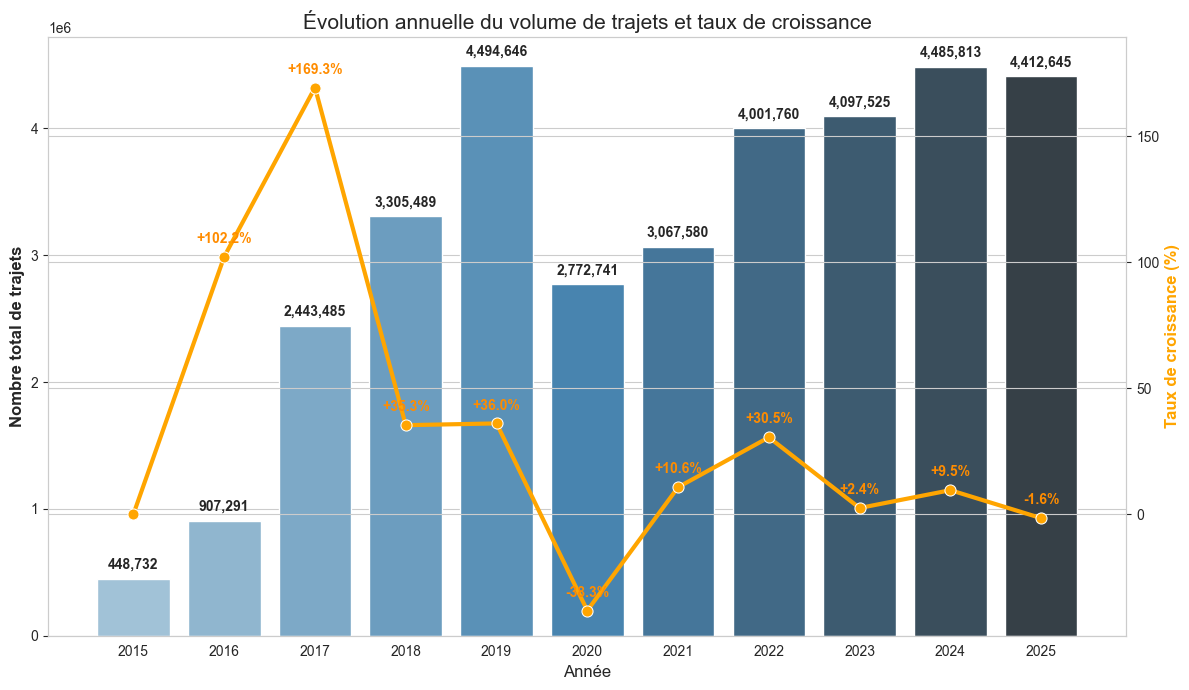

In [37]:
# Calcul du nombre de trajets par année
stats_annuelles = ddf.groupby('annee').size().compute().sort_index()

# Transformation en DataFrame Pandas pour les calculs de croissance
df_croissance = stats_annuelles.reset_index()
df_croissance.columns = ['Année', 'Nombre_Trajets']

# Calcul du Taux de Croissance Annuel (CAGR simplifié d'une année à l'autre)
# (Valeur actuelle - Valeur précédente) / Valeur précédente * 100
df_croissance['Taux_Croissance'] = df_croissance['Nombre_Trajets'].pct_change() * 100

# Pour l'affichage, on remplace le NaN de la première année par 0
df_croissance['Taux_Croissance'] = df_croissance['Taux_Croissance'].fillna(0)

fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Graphique 1 : Volume de trajets (Barres) ---
sns.barplot(data=df_croissance, x='Année', y='Nombre_Trajets', ax=ax1, palette="Blues_d")
ax1.set_ylabel("Nombre total de trajets", fontsize=12, fontweight='bold')
ax1.set_xlabel("Année", fontsize=12)

# Ajout des étiquettes de volume sur les barres
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                 textcoords='offset points')

# --- Graphique 2 : Taux de croissance (Ligne) ---
ax2 = ax1.twinx() # Créer un deuxième axe Y
sns.lineplot(data=df_croissance, x=ax1.get_xticks(), y='Taux_Croissance', 
             ax=ax2, color='orange', marker='o', linewidth=3, markersize=8)

# Ajout des étiquettes de pourcentage sur la ligne
for i, val in enumerate(df_croissance['Taux_Croissance']):
    if i > 0: # On n'affiche pas le 0% de la première année
        ax2.annotate(f'{val:+.1f}%', 
                     (i, val), 
                     textcoords="offset points", xytext=(0,10), 
                     ha='center', color='darkorange', fontweight='bold')

ax2.set_ylabel("Taux de croissance (%)", fontsize=12, color='orange', fontweight='bold')
ax2.set_ylim(df_croissance['Taux_Croissance'].min() - 10, df_croissance['Taux_Croissance'].max() + 20)

plt.title("Évolution annuelle du volume de trajets et taux de croissance", fontsize=15)
plt.tight_layout()
plt.show()

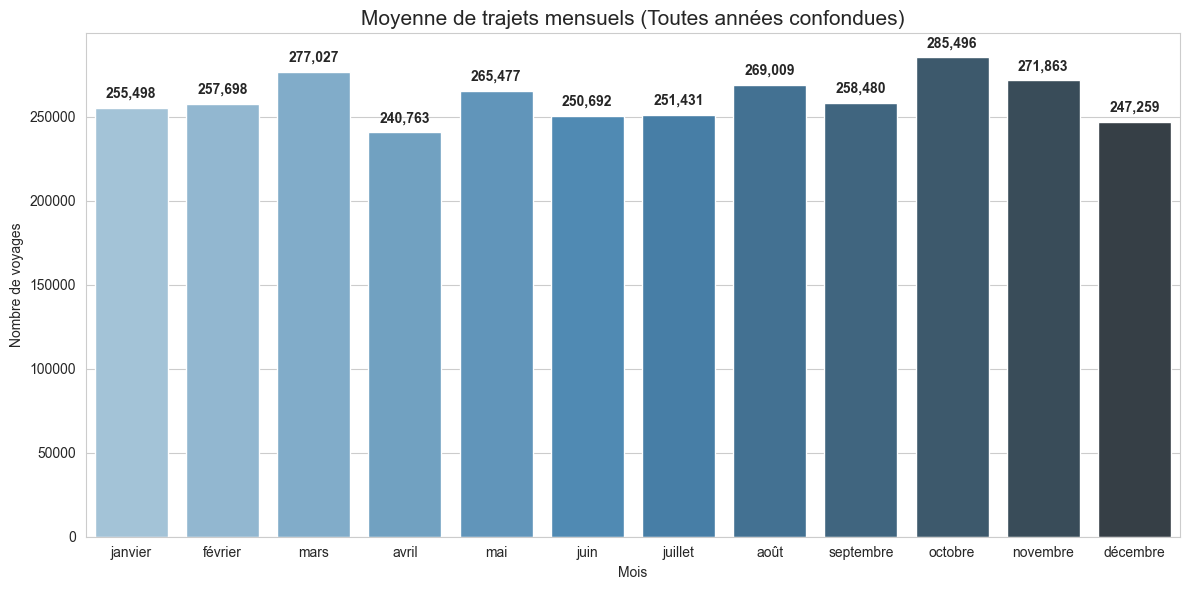

In [38]:
# Calculer le nombre d'années présentes dans le dataframe
nb_annees = ddf['annee'].nunique().compute()

# Grouper par mois et compter les trajets
stats_mensuelles = ddf.groupby('mois').size().compute().sort_index()

# Conversion en DataFrame Pandas pour un affichage propre
df_mois = stats_mensuelles.reset_index()
df_mois.columns = ['Mois_Nom', 'Nombre_Trajets']
df_mois['moy_trajets'] = (df_mois['Nombre_Trajets'] / nb_annees).astype('int32') #Nombre de trajets moyens par mois


liste_mois = ['janvier', 'février', 'mars', 'avril', 'mai', 'juin', 'juillet' ,'août', 'septembre', 'octobre', 'novembre', 'décembre']

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Création du graphique
ax = sns.barplot(data=df_mois, x='Mois_Nom', y='moy_trajets', palette="Blues_d", order=liste_mois)

# Ajout des valeurs au-dessus des barres (formatées avec séparateur de milliers)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')


plt.title("Moyenne de trajets mensuels (Toutes années confondues)", fontsize=15)
plt.ylabel("Nombre de voyages")
plt.xlabel("Mois")
plt.tight_layout()
plt.show()

Calcul du volume de trajets par mois...


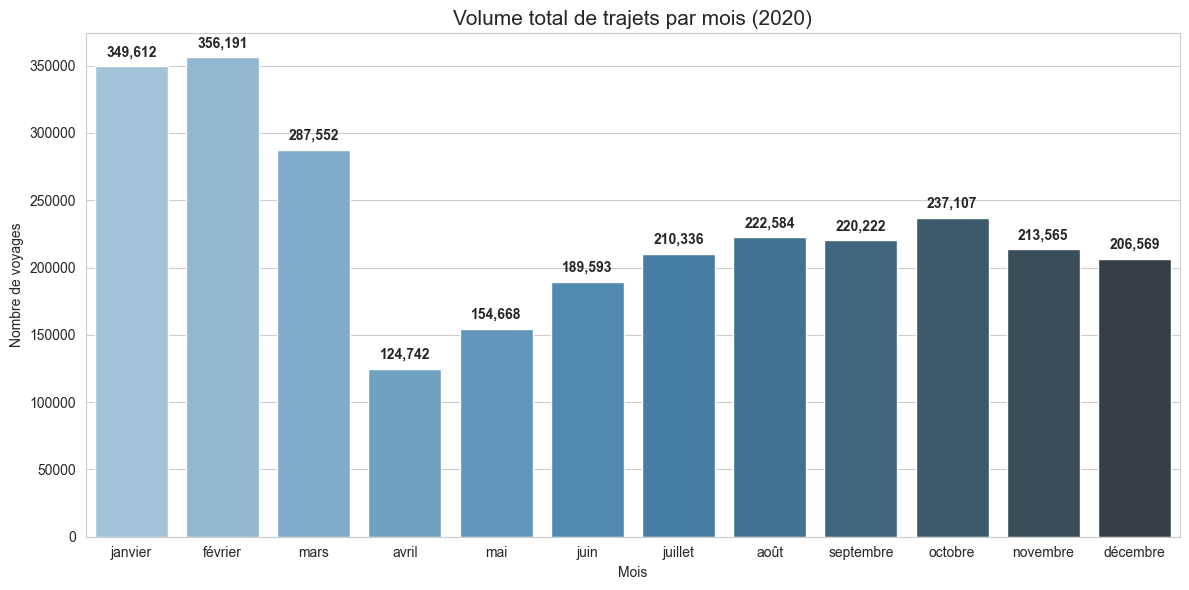

In [39]:
ddf_2020x = ddf[
    (ddf['annee'] == 2020)
]

# Grouper par mois et compter les trajets
print("Calcul du volume de trajets par mois...")
stats_mensuelles_2020 = ddf_2020x.groupby('mois').size().compute().sort_index()

# 2. Conversion en DataFrame Pandas pour un affichage propre
ddf_mois_2020 = stats_mensuelles_2020.reset_index()
ddf_mois_2020.columns = ['Mois_Nom', 'Nombre_Trajets']

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Création du graphique
ax = sns.barplot(data=ddf_mois_2020, x='Mois_Nom', y='Nombre_Trajets', palette="Blues_d", order=liste_mois)

# Ajout des valeurs au-dessus des barres (formatées avec séparateur de milliers)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')


plt.title("Volume total de trajets par mois (2020)", fontsize=15)
plt.ylabel("Nombre de voyages")
plt.xlabel("Mois")
plt.tight_layout()
plt.show()

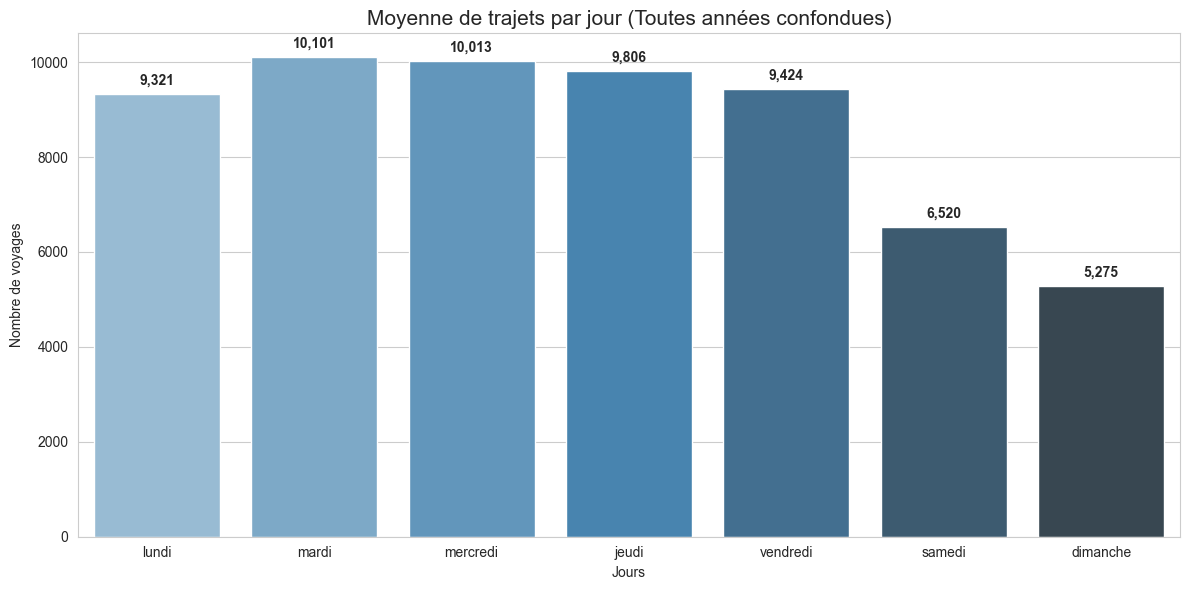

In [40]:
# Calculer le nombre de lundi, mardi, ... (valeur approximative proche de la réalité sur 11 ans)
nb_jours = ddf['debut_trajet'].dt.normalize().nunique().compute()
nb_jours_semaine = nb_jours/7

# Grouper par jour et compter les trajets
stats_hebdomadaires = ddf.groupby('jour').size().compute().sort_index()

# Conversion en DataFrame Pandas pour un affichage propre
df_semaine = stats_hebdomadaires.reset_index()
df_semaine.columns = ['Jour_Nom', 'Nombre_Trajets']
df_semaine['moy_trajets'] = (df_semaine['Nombre_Trajets'] / nb_jours_semaine).astype('int32')

liste_jours = ['lundi', 'mardi', 'mercredi', 'jeudi', 'vendredi', 'samedi', 'dimanche']

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Création du graphique
ax = sns.barplot(data=df_semaine, x='Jour_Nom', y='moy_trajets', palette="Blues_d", order=liste_jours)

# Ajout des valeurs au-dessus des barres (formatées avec séparateur de milliers)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')


plt.title("Moyenne de trajets par jour (Toutes années confondues)", fontsize=15)
plt.ylabel("Nombre de voyages")
plt.xlabel("Jours")
plt.tight_layout()
plt.show()

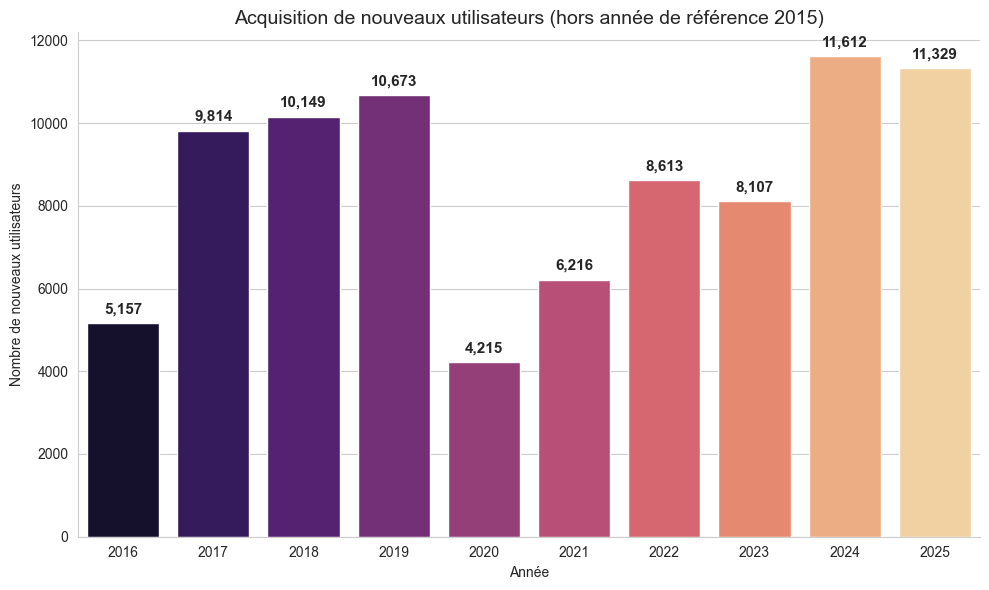

In [41]:
# Trouver l'année minimum pour chaque utilisateur
first_appearance = ddf.groupby('id_utilisateur')['annee'].min().compute()

# Compter combien d'utilisateurs ont commencé chaque année
nouveaux_utilisateurs = first_appearance.value_counts().sort_index().reset_index()
nouveaux_utilisateurs.columns = ['Année', 'Nouveaux_Utilisateurs']

# Calcul du taux de croissance des nouveaux inscrits (optionnel)
nouveaux_utilisateurs['Evolution_Acquisition'] = nouveaux_utilisateurs['Nouveaux_Utilisateurs'].pct_change() * 100

# On identifie l'année de départ du jeu de données
annee_debut = nouveaux_utilisateurs['Année'].min()

# On filtre pour ne garder que les années suivantes
df_attractivite_reelle = nouveaux_utilisateurs[nouveaux_utilisateurs['Année'] > annee_debut]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Création du graphique à partir de l'année N+1
ax = sns.barplot(
    data=df_attractivite_reelle, 
    x='Année', 
    y='Nouveaux_Utilisateurs', 
    palette="magma"
)

# Ajout des étiquettes
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')



plt.title(f"Acquisition de nouveaux utilisateurs (hors année de référence {annee_debut})", fontsize=14)
plt.ylabel("Nombre de nouveaux utilisateurs")
plt.xlabel("Année")

sns.despine()
plt.tight_layout()
plt.show()

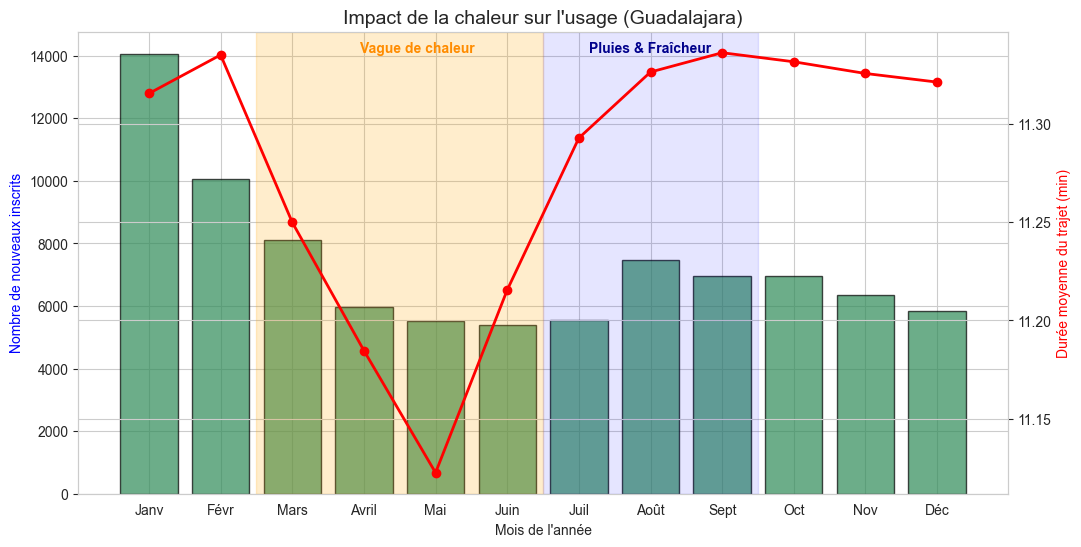

In [42]:
dict_mois_vers_num = {
    'janvier': 1, 'février': 2, 'mars': 3, 'avril': 4, 'mai': 5, 'juin': 6,
    'juillet': 7, 'août': 8, 'septembre': 9, 'octobre': 10, 'novembre': 11, 'décembre': 12
}

# On trouve la date de première apparition pour chaque usager
# On crée une colonne temporaire 'tri' pour identifier la chronologie (Annee + Mois)
# On mappe le dictionnaire sur la colonne mois
ddf['num_mois'] = ddf['mois'].str.lower().map(dict_mois_vers_num, meta=('num_mois', 'int32'))
ddf['tri_temp'] = ddf['annee'] * 100 + ddf['num_mois']

# On récupère le mois (numérique) du tout premier trajet
premiers_trajets = ddf.groupby('id_utilisateur')['tri_temp'].min().reset_index()
premiers_trajets['mois_premier_trajet'] = premiers_trajets['tri_temp'] % 100
premiers_trajets = premiers_trajets[premiers_trajets['tri_temp'] > 201501]

# On compte le total par mois sur toutes les années
stats_recrutement = premiers_trajets.groupby('mois_premier_trajet').size().compute().sort_index()

# calcul de la durée moyenne de trajet par mois
duree_par_mois = ddf.groupby('num_mois')['temps_trajet'].mean().compute().sort_index()

# Les labels pour l'axe X (dans l'ordre 1 à 12)
labels_mois = ['Janv', 'Févr', 'Mars', 'Avril', 'Mai', 'Juin', 
               'Juil', 'Août', 'Sept', 'Oct', 'Nov', 'Déc']

fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe 1 : Le recrutement (votre analyse précédente)
ax1.bar(labels_mois, stats_recrutement.values, color='#2E8B57', edgecolor = 'black', alpha=0.7, label='Nouveaux Usagers')
ax1.set_ylabel('Nombre de nouveaux inscrits', color='blue')

# Axe 2 : La durée moyenne des trajets
ax2 = ax1.twinx()
ax2.plot(labels_mois, duree_par_mois.values, color='red', marker='o', linewidth=2, label='Durée moyenne')
ax2.set_ylabel('Durée moyenne du trajet (min)', color='red')

plt.title("Impact de la chaleur sur l'usage (Guadalajara)", fontsize=14)
ax1.set_xlabel("Mois de l'année")

# Zone de chaleur (Mars-Juin)
plt.axvspan(1.5, 5.5, color='orange', alpha=0.2)
plt.axvspan(5.5, 8.5, color='blue', alpha=0.1, label='Saison des Pluies')
plt.text(3.75, duree_par_mois.max(), "Vague de chaleur", ha='center', weight='bold', color='darkorange')
plt.text(7, duree_par_mois.max(), "Pluies & Fraîcheur", ha='center', color='darkblue', weight='bold')


plt.show()

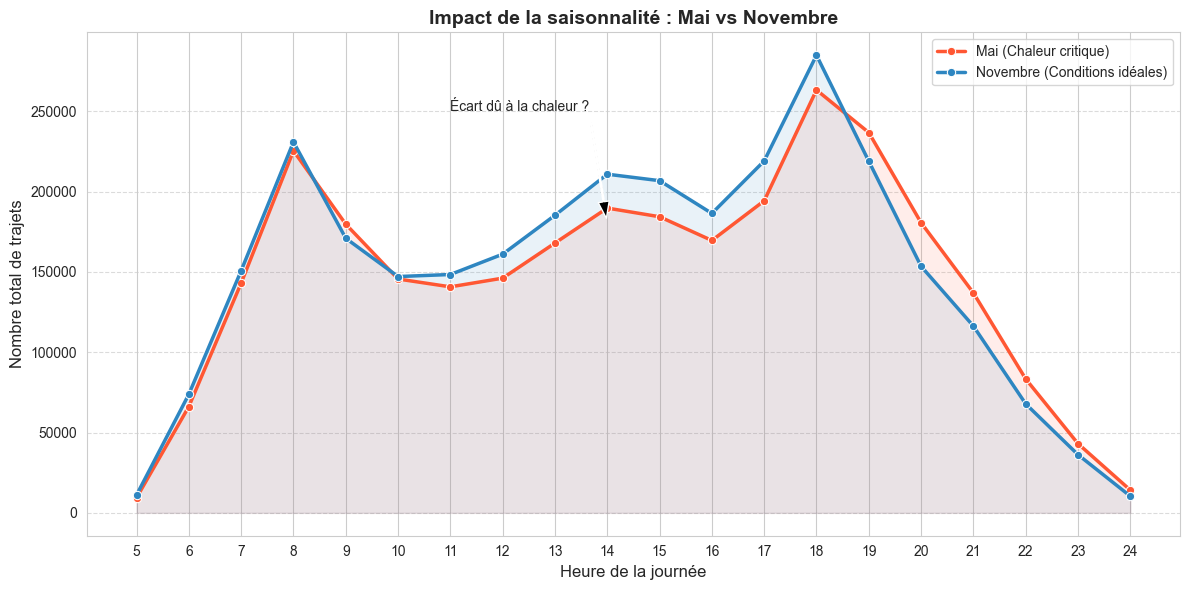

In [43]:
# On compte les trajets pour chaque combinaison Mois/Heure
heatmap_data = ddf.groupby(['mois', 'heure_debut']).size().compute().reset_index()
heatmap_data.columns = ['Mois', 'Heure', 'Nombre_Trajets']

# Pivotage des données (Transformation en matrice)
pivot_table = heatmap_data.pivot(index='Mois', columns='Heure', values='Nombre_Trajets')

# Réorganiser les mois chronologiquement (pour éviter l'ordre alphabétique)
ordre_mois = ['janvier', 'février', 'mars', 'avril', 'mai', 'juin', 
              'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre']
pivot_table = pivot_table.reindex(ordre_mois)

# On extrait les lignes correspondant à Mai et Novembre de notre pivot_table
# Ces 2 mois ont été choisis car ils présentent un volume similaire de trajets.
focus_mois = pivot_table.loc[['mai', 'novembre']].transpose()

# Création du graphique
plt.figure(figsize=(12, 6))

# Tracer la courbe pour Avril
sns.lineplot(data=focus_mois, x=focus_mois.index, y='mai', 
             marker='o', label='Mai (Chaleur critique)', color='#FF5733', linewidth=2.5)

# Tracer la courbe pour Octobre
sns.lineplot(data=focus_mois, x=focus_mois.index, y='novembre', 
             marker='o', label='Novembre (Conditions idéales)', color='#2E86C1', linewidth=2.5)

# Personnalisation des titres et légendes
plt.fill_between(focus_mois.index, focus_mois['mai'], alpha=0.1, color='#FF5733')
plt.fill_between(focus_mois.index, focus_mois['novembre'], alpha=0.1, color='#2E86C1')

plt.title("Impact de la saisonnalité : Mai vs Novembre", fontsize=14, fontweight='bold')
plt.xlabel("Heure de la journée", fontsize=12)
plt.ylabel("Nombre total de trajets", fontsize=12)
plt.xticks(focus_mois.index) # Affiche toutes les heures de 5 à 24h
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# Annotation du "gap" de l'après-midi
plt.annotate('Écart dû à la chaleur ?', xy=(14, 180000), xytext=(11, 250000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8))

plt.tight_layout()
plt.show()

 - **Le coup d'arrêt du Covid et le retour à la normale**\
 Après le lancement du service en décembre 2014, le service connait un coup d'arrêt lié à la pandémie du Covid-19 en 2020 avec une chute du volume de trajets de 38% et un nombre de nouveaux abonnés qui atteint son plus bas historique (-60% de nouveaux usagers par rapport à 2019).\
 Le service reprendra progressivement sa croissance, ne retrouvant son niveau d'avant-pandémie qu'en 2024 mais avec un nombre record de nouveaux usagers cette année-là.  
 L'année 2025 révèle un essoufflement global du service. Le volume (-1,6%) et l'acquisition (-2,4%) reculent, nous sommes face à un plafond de verre infrastructurel.  
 Le réseau étant saturé, il faut investir dans la capacité du réseau, plutôt que dans l'acquisition de nouveaux clients.
   
- **La dynamique hebdomadaire : un outil de travail**\
Avec 9700 trajets quotidiens en semaine, contre 5900 le week-end soit 40% de moins, le réseau Mibici est un réseau pendulaire (domicile-travail) plus qu'un réseau pour touristes. Il est utile aux habitants.  
  
- **L'énigme du printemps**  
On observe un trou d'air systématique au printemps (moins de trajets, moins de nouveaux membres et une durée moyenne de trajets qui diminue), c'est la période de l'année la plus aride et chaude à Guadalajara.   
Si on compare mai et novembre, on observe un report des usages après 20h durant le printemps. Les habitants privilégient d'autres modes de transport pour éviter l'exposition au soleil.

## 2. Sociologie et Comportement des Usagers

In [ ]:
''' Il s'agit ici de la moyenne d'âge des trajets et non des usagers
Ainsi les utilisateurs les plus réguliers créent un biais'''

print(f"La moyenne d'âge est de {ddf_age['age'].mean().compute():.1f} ans")

La moyenne d'âge est de 33.2 ans


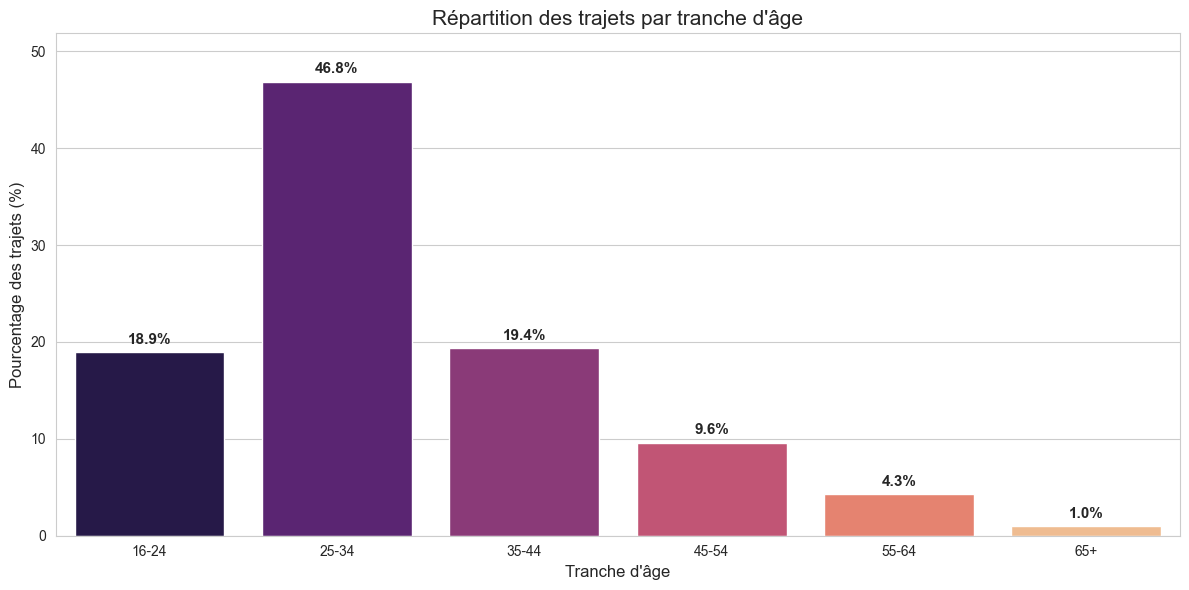

In [45]:
age_counts = ddf_age['age'].value_counts().compute()

df_ages = age_counts.reset_index()
df_ages.columns = ['age', 'nombre']
df_ages.sort_values(by=["age"], inplace=True) # Trier par ordre croissant d'âge

# Définition des bornes et des étiquettes
bins_age = [15, 24, 34, 44, 54, 64, 100]
labels_age = ["16-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df_ages['categorie_age'] = pd.cut(
    df_ages['age'], 
    bins=bins_age, 
    labels=labels_age, 
    right=True, 
    include_lowest=True
)

# On agrège par catégorie pour avoir le total par tranche
cat_age = df_ages.groupby('categorie_age', observed=True)['nombre'].sum().reset_index()

# Calcul du pourcentage
total_trajets = cat_age['nombre'].sum()
cat_age['pourcentage'] = (cat_age['nombre'] / total_trajets) * 100

# --- Visualisation ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(data=cat_age, x='categorie_age', y='pourcentage', palette="magma")

# Ajout des % au dessus des barres
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontsize=11, fontweight='bold')

plt.title("Répartition des trajets par tranche d'âge", fontsize=15)
plt.ylabel("Pourcentage des trajets (%)", fontsize=12)
plt.xlabel("Tranche d'âge", fontsize=12)
plt.ylim(0, cat_age['pourcentage'].max() + 5)

plt.tight_layout()
plt.show()

### Analyse de la différence de comportements homme/femme

In [ ]:
# Création d'un dataframe d'usagers uniques
df_unique_users = ddf_age[['id_utilisateur', 'genre']].drop_duplicates(subset=['id_utilisateur']).compute()

# Calcul de la répartition de genre parmi les usagers
repartition_individus = df_unique_users.groupby('genre').size().reset_index()
repartition_individus.columns = ['Sexe', 'Nombre'] # renommer les colonnes
repartition_individus['Sexe'] = repartition_individus['Sexe'].replace({'M': 'Homme', 'F': 'Femme'}) # Renommer M et F pour plus de lisibilité

total_individus = repartition_individus['Nombre'].sum() # Calcul de la somme total de personnes
repartition_individus['Pourcentage'] = (repartition_individus['Nombre'] / total_individus) * 100 # ajout de la colonne pourcentage

print(f'Les {repartition_individus.loc[0,'Sexe'].lower() + 's'} représentent {repartition_individus.loc[0,'Pourcentage']:.2f} % et les {repartition_individus.loc[1,'Sexe'].lower() + 's'} {repartition_individus.loc[1,'Pourcentage']:.2f} % des usagers' )

Les femmes représentent 37.45 % et les hommes 62.55 % des usagers


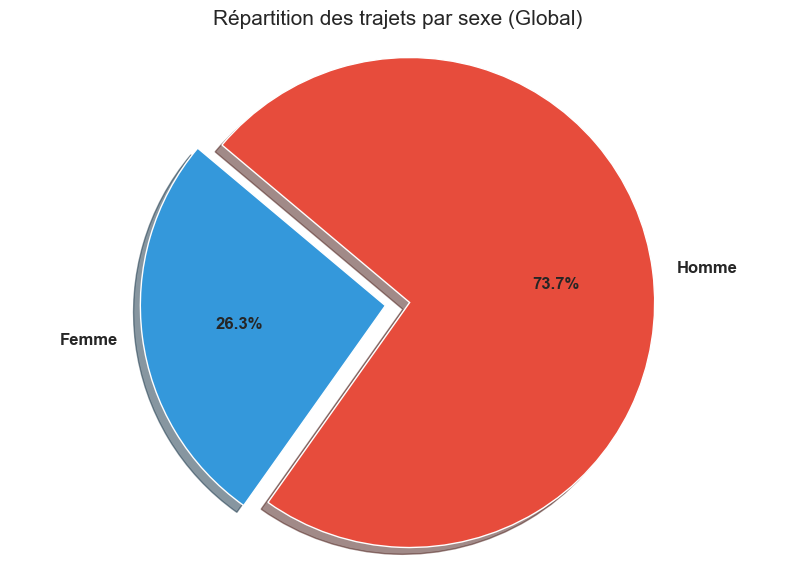

In [47]:
# Calcul de la répartition des trajets par sexe
repartition_genre = ddf["genre"].value_counts().compute()
repartition_genre = repartition_genre.reset_index()
repartition_genre.columns = ['Sexe', 'Nombre'] # renommer les colonnes
repartition_genre['Sexe'] = repartition_genre['Sexe'].replace({'M': 'Homme', 'F': 'Femme'}) # Renommer M et F pour plus de lisibilité

total_trajets = repartition_genre['Nombre'].sum() # Calcul de la somme totale de trajets
repartition_genre['Pourcentage'] = (repartition_genre['Nombre'] / total_trajets) * 100 # ajour de la colonne pourcentage

# Données pour le graphique
labels_genre = repartition_genre['Sexe']
tailles = repartition_genre['Nombre']
couleurs = ['#3498db', '#e74c3c', '#95a5a6'] # Bleu, Rouge, Gris

# Création de la figure
plt.figure(figsize=(10, 7))

# Tracer le camembert
plt.pie(
    tailles, 
    labels=labels_genre, 
    autopct='%1.1f%%', # Affiche le pourcentage avec une décimale
    startangle=140,    # Rotation pour une meilleure esthétique
    colors=couleurs,
    explode=(0.05, 0.05) if len(tailles) == 2 else None, # Détache légèrement les morceaux
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title("Répartition des trajets par sexe (Global)", fontsize=15)
plt.axis('equal') # Garantit que le camembert est bien un cercle
plt.show()

<Figure size 1200x700 with 0 Axes>

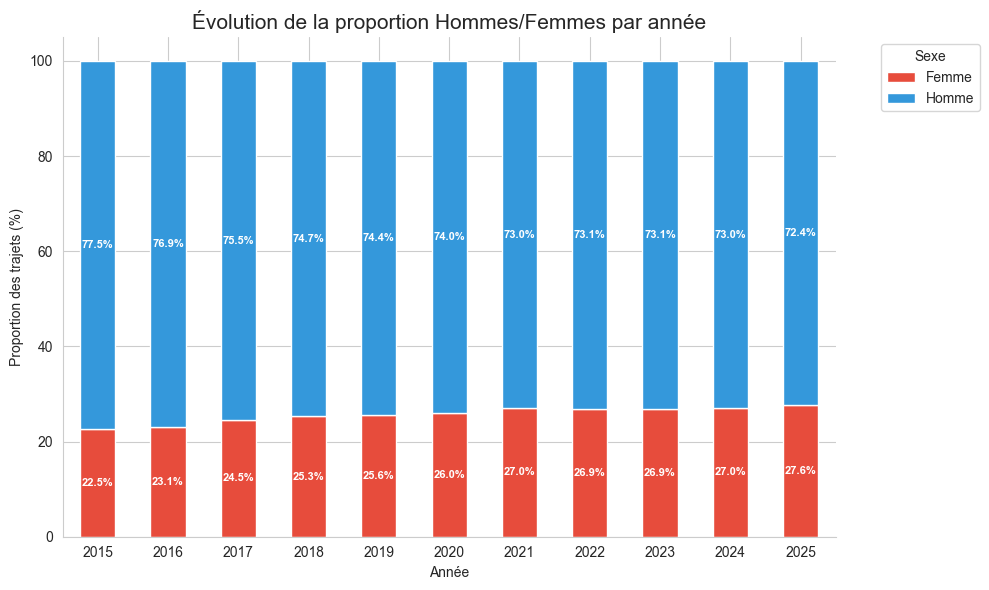

In [48]:
genre_annee = ddf.groupby(['annee', 'genre']).size().compute().reset_index()
genre_annee.columns = ['Année', 'Sexe', 'Nombre']
genre_annee['Sexe'] = genre_annee['Sexe'].replace({'M': 'Homme', 'F': 'Femme'})

# On divise le nombre de chaque sexe par le total de son année respective
genre_annee['Pourcentage'] = genre_annee.groupby('Année')['Nombre'].transform(lambda x: (x / x.sum()) * 100)

repartition_genre_par_annee = genre_annee.pivot(index='Année', columns='Sexe', values='Pourcentage')

# Création du graphique
plt.figure(figsize=(12, 7))

# On utilise la méthode plot de Pandas qui gère très bien l'empilement (stacked)
ax = repartition_genre_par_annee.plot(kind='bar', stacked=True, color=['#e74c3c', '#3498db'], figsize=(10,6))

# Ajout des annotations de pourcentage au centre des segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # On n'affiche le texte que si le segment est assez large
        x, y = p.get_xy() 
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', va='center', 
                color='white', fontweight='bold', fontsize=8)



plt.title("Évolution de la proportion Hommes/Femmes par année", fontsize=15)
plt.ylabel("Proportion des trajets (%)")
plt.xlabel("Année")
plt.legend(title="Sexe", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
sns.despine()

plt.tight_layout()
plt.show()

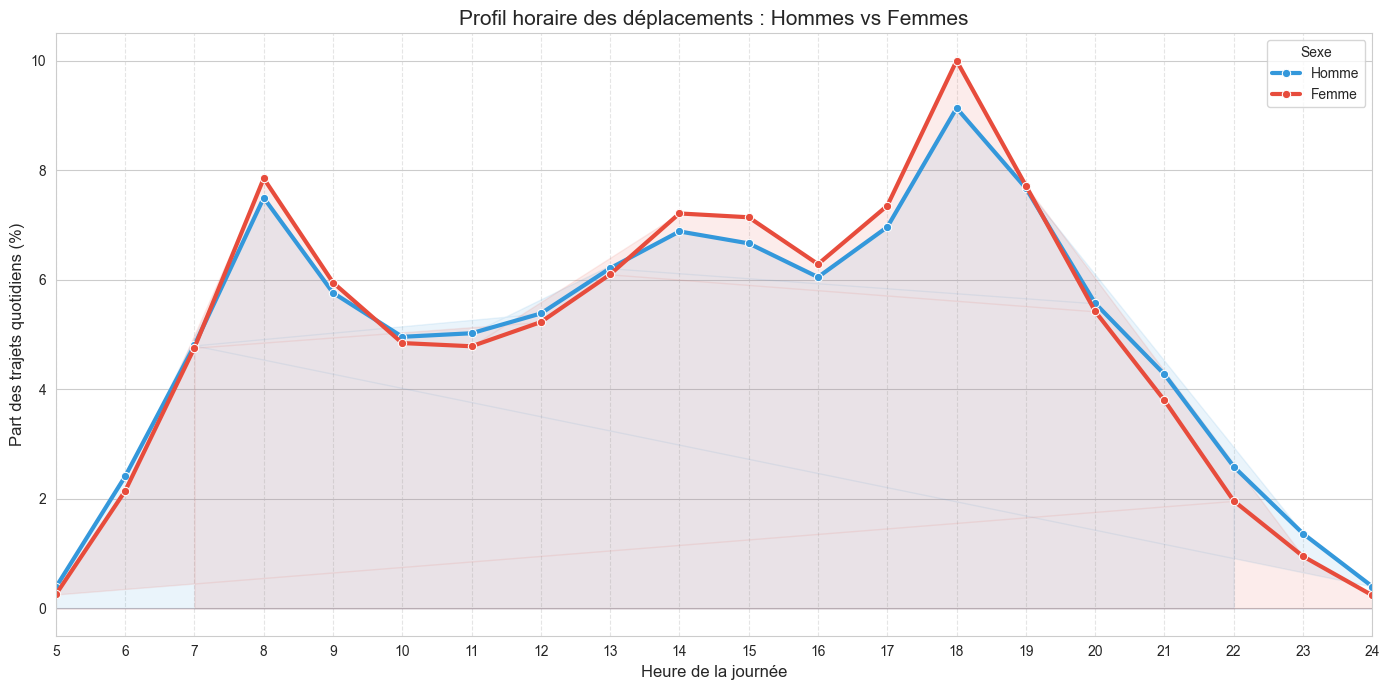

In [49]:
# Groupement par heure et par sexe
stats_horaires_sexe = ddf.groupby(['heure_debut', 'genre']).size().compute()
df_h_sexe = stats_horaires_sexe.reset_index()
df_h_sexe.columns = ['Heure', 'Sexe', 'Nombre_Trajets']

# Nettoyage des noms pour la légende
df_h_sexe['Sexe'] = df_h_sexe['Sexe'].replace({'M': 'Homme', 'F': 'Femme'})

# Normalisation
# Pour comparer les comportements plutôt que les volumes (s'il y a beaucoup plus d'hommes que de femmes)
# On calcule la part que représente chaque heure pour chaque sexe
df_h_sexe['Proportion'] = df_h_sexe.groupby('Sexe')['Nombre_Trajets'].transform(lambda x: x / x.sum() * 100)

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Palette de couleurs cohérente
palette_sexe = {"Homme": "#3498db", "Femme": "#e74c3c"}

# Tracer les lignes d'évolution
sns.lineplot(
    data=df_h_sexe, 
    x='Heure', 
    y='Proportion', 
    hue='Sexe', 
    palette=palette_sexe, 
    linewidth=3, 
    marker='o'
)

# Remplissage sous les courbes pour mieux voir les volumes
for sexe, color in palette_sexe.items():
    subset = df_h_sexe[df_h_sexe['Sexe'] == sexe]
    plt.fill_between(subset['Heure'], subset['Proportion'], alpha=0.1, color=color)

# Configuration de l'axe X (de 5h à 23h)
plt.xticks(range(5, 25))
plt.xlim(5, 24)

plt.title("Profil horaire des déplacements : Hommes vs Femmes", fontsize=15)
plt.ylabel("Part des trajets quotidiens (%)", fontsize=12)
plt.xlabel("Heure de la journée", fontsize=12)
plt.legend(title="Sexe")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [50]:
# Calcul des flux par station de départ et par sexe
geo_stats = ddf.groupby(['nom_station_depart', 'genre', 'lat_depart', 'lon_depart']).size().compute()

df_geo = geo_stats.reset_index()
df_geo.columns = ['Station', 'Sexe', 'Lat', 'Lon', 'Frequentation']

# Séparation des données pour comparer
df_femmes = df_geo[df_geo['Sexe'] == 'F']
df_hommes = df_geo[df_geo['Sexe'] == 'M']

# Calcul des moyennes de coordonnées pour centrer la carte automatiquement
lat_center = df_geo['Lat'].mean()
lon_center = df_geo['Lon'].mean()

# Préparation des listes de données pour la heatmap
data_femmes = df_geo[df_geo['Sexe'] == 'F'][['Lat', 'Lon', 'Frequentation']].values.tolist()
data_hommes = df_geo[df_geo['Sexe'] == 'M'][['Lat', 'Lon', 'Frequentation']].values.tolist()

# Création de la carte centrée sur les coordonnées moyennes
m = folium.Map(location=[lat_center, lon_center], zoom_start=13, tiles='cartodbpositron')

# Ajout de la Heatmap pour les Femmes
layer_f = folium.FeatureGroup(name='Densité Femmes')
HeatMap(data_femmes, radius=15, blur=20, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(layer_f)

# Ajout de la Heatmap pour les Hommes
layer_m = folium.FeatureGroup(name='Densité Hommes')
HeatMap(data_hommes, radius=15, blur=20, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(layer_m)

# Ajouter les couches et le contrôle
layer_f.add_to(m)
layer_m.add_to(m)
folium.LayerControl().add_to(m)

# Sauvegarde
m.save('heatmap_frequentation.html')

m

In [51]:
# On regroupe par usager pour avoir son "espérance de vie" dans le service
user_life = ddf.groupby('id_utilisateur')['debut_trajet'].agg(['min', 'max']).compute()

# Calcul de l'ancienneté en jours
user_life['anciennete_jours'] = (user_life['max'] - user_life['min']).dt.days

total_users = len(user_life)

''' On filtre pour ne garder que ceux qui ont eu leur premier trajet 
il y a assez longtemps pour pouvoir être comptés (au moins 1 an avant la fin du dataset)
Sinon, un nouvel inscrit d'hier ferait baisser le taux de fidélisation à 1 an à tort '''
user_life = user_life[user_life['min'] < '2025-01-01 00:00:00']

fid_30j = (user_life['anciennete_jours'] >= 30).sum() / total_users * 100
fid_90j = (user_life['anciennete_jours'] >= 90).sum() / total_users * 100
fid_1an = (user_life['anciennete_jours'] >= 365).sum() / total_users * 100

print(f"Taux de fidélisation à 30 jours : {fid_30j:.2f}%")
print(f"Taux de fidélisation à 90 jours : {fid_90j:.2f}%")
print(f"Taux de fidélisation à 1 an     : {fid_1an:.2f}%")

Taux de fidélisation à 30 jours : 79.80%
Taux de fidélisation à 90 jours : 75.80%
Taux de fidélisation à 1 an     : 46.89%


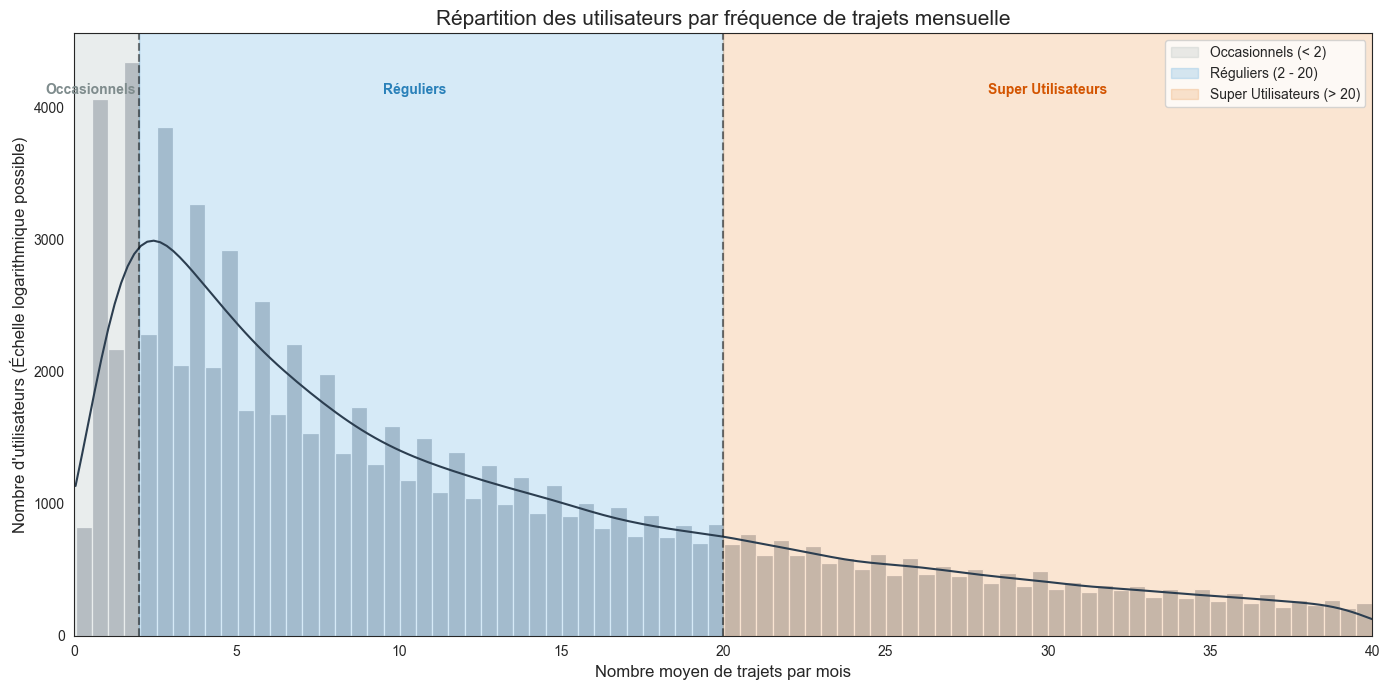

In [53]:
# Calcul du nombre de trajets et de la période d'activité par utilisateur
# On récupère le nombre de trajets, la date du premier et du dernier voyage
user_stats = ddf.groupby('id_utilisateur').agg({
    'debut_trajet': ['count', 'min', 'max']
}).compute()

# Nettoyage des colonnes (Dask crée un MultiIndex lors de l'agg)
user_stats.columns = ['nb_trajets', 'premier_voyage', 'dernier_voyage']
user_stats = user_stats.reset_index()

# Calcul de la durée d'activité en mois
# On définit la durée minimale à 1 mois pour éviter la division par zéro
def calculer_mois(row):
    diff = (row['dernier_voyage'] - row['premier_voyage']).days / 30.44
    return max(1, round(diff))

user_stats['duree_mois'] = user_stats.apply(calculer_mois, axis=1)

# Calcul de la fréquence (trajets par mois)
user_stats['trajets_par_mois'] = user_stats['nb_trajets'] / user_stats['duree_mois']

# Définition du type d'utilisateur
''' On choisit 2 voyages par mois pour la délimitation occasionnel/régulier pour éviter que les utilisateurs n'ayant effectué qu'un seul voyage donc avec une fréquence de 1 soient catégorisés comme réguliers
La limite de 20 voyages mensuels pour la délimitation régulier/super_utilisateur correspond à un voyage par jour de la semaine'''
def segmenter_utilisateur(freq):
    if freq >= 20:
        return 'Super Utilisateur'
    elif freq >= 2:
        return 'Régulier'
    else:
        return 'Occasionnel'

user_stats['categorie_usager'] = user_stats['trajets_par_mois'].apply(segmenter_utilisateur)

# Calcul des résultats finaux
repartition_usagers = user_stats['categorie_usager'].value_counts(normalize=True) * 100


# On limite à 40 trajets/mois pour garder une bonne visibilité (le reste est marginal)
df_viz = user_stats[user_stats['trajets_par_mois'] <= 40].copy()

# On définit les couleurs pour chaque zone
# Gris = Occasionnels, Bleu = Réguliers, Orange = Super Utilisateurs
palette = {'Occasionnel': '#95a5a6', 'Régulier': '#3498db', 'Super Utilisateur': '#e67e22'}

plt.figure(figsize=(14, 7))
sns.set_style("white")

# Tracer l'histogramme global
ax = sns.histplot(data=df_viz, x='trajets_par_mois', bins=80, kde=True, color="#2c3e50", alpha=0.3)

# Colorer les zones de segmentation
plt.axvspan(0, 2, color=palette['Occasionnel'], alpha=0.2, label='Occasionnels (< 2)')
plt.axvspan(2, 20, color=palette['Régulier'], alpha=0.2, label='Réguliers (2 - 20)')
plt.axvspan(20, 40, color=palette['Super Utilisateur'], alpha=0.2, label='Super Utilisateurs (> 20)')

# Ajouter les lignes de démarcation verticales
plt.axvline(x=2, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=20, color='black', linestyle='--', alpha=0.5)



# Annotations pour clarifier les seuils
plt.text(0.5, plt.ylim()[1]*0.9, "Occasionnels", ha='center', fontweight='bold', color='#7f8c8d')
plt.text(10.5, plt.ylim()[1]*0.9, "Réguliers", ha='center', fontweight='bold', color='#2980b9')
plt.text(30, plt.ylim()[1]*0.9, "Super Utilisateurs", ha='center', fontweight='bold', color='#d35400')

plt.xlim(left=0, right=40)

plt.title("Répartition des utilisateurs par fréquence de trajets mensuelle", fontsize=15)
plt.xlabel("Nombre moyen de trajets par mois", fontsize=12)
plt.ylabel("Nombre d'utilisateurs (Échelle logarithmique possible)", fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

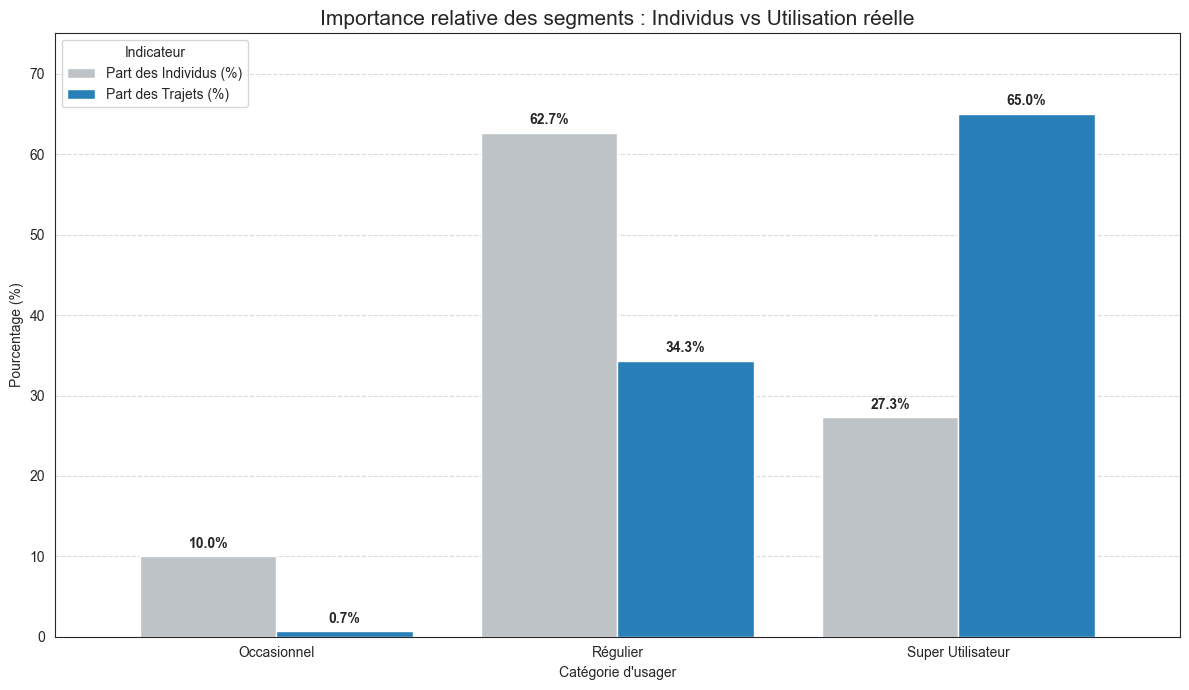

In [54]:
# Calcul du poids en nombre de trajets
poids_trajets = user_stats.groupby('categorie_usager')['nb_trajets'].sum()
poids_trajets_pct = (poids_trajets / poids_trajets.sum()) * 100


# Préparation des données pour la comparaison
# On regroupe les deux statistiques calculées précédemment
df_comparatif = pd.DataFrame({
    'Part des Individus (%)': repartition_usagers,
    'Part des Trajets (%)': poids_trajets_pct
}).reindex(['Occasionnel', 'Régulier', 'Super Utilisateur'])

# Création du graphique en barres groupées
ax = df_comparatif.plot(kind='bar', figsize=(12, 7), color=['#bdc3c7', '#2980b9'], width=0.8)

# Ajout des étiquettes de pourcentage sur les barres
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points', fontweight='bold')



# Personnalisation esthétique
plt.title("Importance relative des segments : Individus vs Utilisation réelle", fontsize=15)
plt.ylabel("Pourcentage (%)")
plt.xlabel("Catégorie d'usager")
plt.xticks(rotation=0)
plt.ylim(0, max(df_comparatif.max()) + 10)
plt.legend(title="Indicateur")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

- **Profil des utilisateurs**  
L'utilisateur moyen est un homme autour de la trentaine (moyenne d'âge à 33 ans), qui effectue entre 2 et 20 trajets par mois  
Le service est principalement utilisé par les jeunes actifs (25-34 ans) qui représentent près de la moitié des utilisateurs (46,8%)
Les hommes représentent près de 3/4 des usagers, ce qui est raccord avec [la sociologie du vélo](https://journals.openedition.org/rsa/4963) et les données obtenues dans d'autres villes comme [Paris](https://research.systematica.net/journal/unveiling-womens-needs-and-expectations-as-users-of-bike-sharing-services/)  
Bien que peu nombreux (27,3% des usagers), les super-utilisateurs représentent près de 2/3 des trajets. A l'inverse, les usagers réguliers ne portent qu'un peu plus du tiers des trajets quand ils constituent plus de 60% des usagers.
- **Usage féminin**  
Les femmes représentent 37% des usagers mais seulement 27% des trajets, chiffre en stagnation depuis 5 ans.  
Si on n'observe pas vraiment de difference spatiale liée au genre qui indiquerait que certains lieux sont évités par les femmes, elles sont moins nombreuses dans les trajets après 20h quand la luminosité diminue, signe que la question de la sécurité reste un enjeu majeur pour une adoption plus large du service par les femmes
- **Fidélisation**  
Avec un taux de rétention à 80%, 8 usagers sur 10 qui testent le service l'adoptent le mois suivant. La baisse à 3 mois est infime (76%), ceux qui passent le premier mois deviennent quasi-systématiquement des usagers réguliers.  
Enfin, près de la moitié des inscrits utilisent encore le service un an plus tard. C'est un taux de "conversion en cycliste urbain" très solide, surtout si l'on considère les déménagements, les changements d'emploi ou l'achat d'un vélo personnel.

## 3. Efficacite Operationnelle

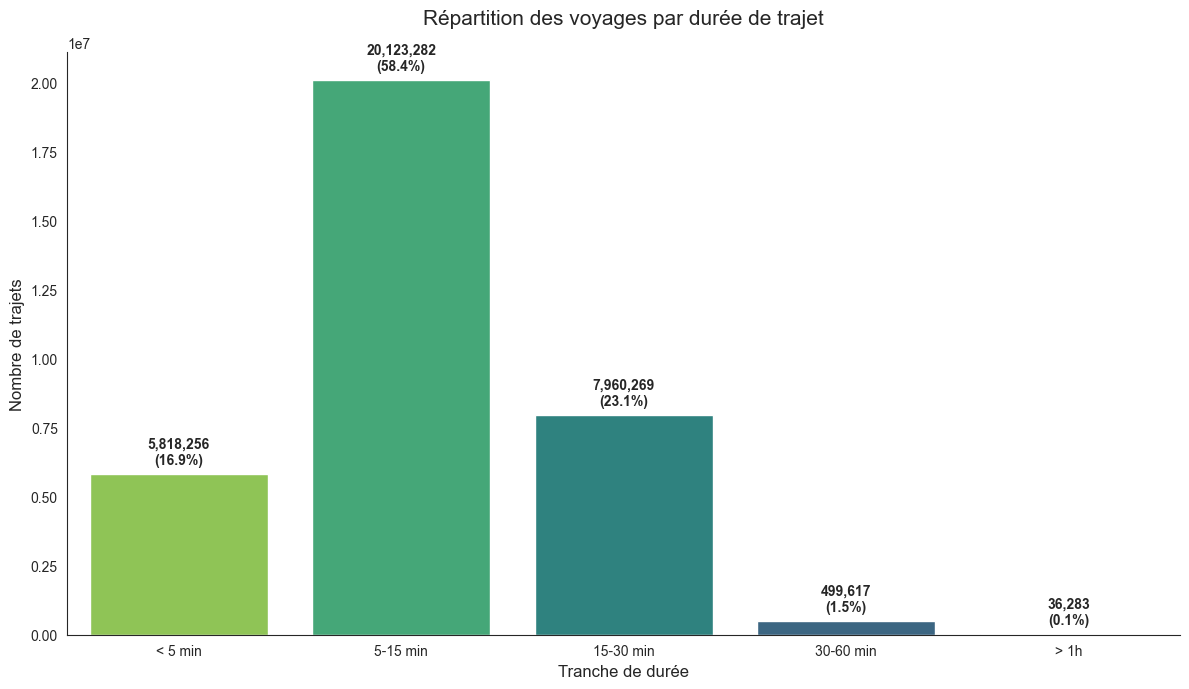

In [55]:
# Définition des bornes et des étiquettes
bins_duree = [0, 5, 15, 30, 60, 1440] # 1440 min = 24h
labels_duree = ['< 5 min', '5-15 min', '15-30 min', '30-60 min', '> 1h']

type_duree = CategoricalDtype(categories=labels_duree, ordered=True)
# Calcul des tranches (en utilisant map_partitions pour l'efficacité Dask)
def segmenter_duree(df):
    return pd.cut(df['temps_trajet'], bins=bins_duree, labels=labels_duree, right=False).astype(type_duree)

ddf['tranche_duree'] = ddf.map_partitions(
    segmenter_duree, 
    meta=pd.Series([], dtype=type_duree, name='tranche_duree')
)

# Comptage des trajets par tranche
stats_duree = ddf['tranche_duree'].value_counts().compute().reindex(labels_duree).fillna(0)
df_duree_viz = stats_duree.reset_index()
df_duree_viz.columns = ['Tranche', 'Nombre_Trajets']

plt.figure(figsize=(12, 7))
sns.set_style("white")

# Palette dégradée du vert (court) au rouge (long)
palette_duree = sns.color_palette("viridis_r", len(labels_duree))

ax = sns.barplot(data=df_duree_viz, x='Tranche', y='Nombre_Trajets', palette=palette_duree)

# Ajout des étiquettes de volume et de pourcentage
total = df_duree_viz['Nombre_Trajets'].sum()
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(f'{int(p.get_height()):,}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.title("Répartition des voyages par durée de trajet", fontsize=15, pad=20)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.xlabel("Tranche de durée", fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
''' Recherche du nom d'une station à partir de son id ou de l'id à partir du nom de la station'''

# On extrait uniquement les colonnes ID et Nom, et on supprime les doublons
# On utilise 'id_depart' et 'nom_station_depart' car ce sont les mêmes que pour l'arrivée
referentiel_stations = ddf[['id_depart', 'nom_station_depart']].drop_duplicates().compute()

# On renomme pour que ce soit propre
referentiel_stations.columns = ['id_station', 'nom_station']

# On trie par ID pour faciliter la lecture
referentiel_stations = referentiel_stations.sort_values('id_station').set_index('id_station')

def trouver_nom_station(id_recherche):
    """Chercher le nom complet d'une station à partir de son id"""
    try:
        nom = referentiel_stations.loc[id_recherche, 'nom_station']
        print(f"La station {id_recherche} est : {nom}")
    except KeyError:
        print(f"L'ID {id_recherche} n'existe pas dans la base.")

def trouver_id(nom_station_partiel):
    """
    Cherche une station par son nom (ou une partie du nom)
    et affiche l'ID et le nom complet.
    """
    matches = referentiel_stations[referentiel_stations['nom_station'].str.contains(nom_station_partiel, case=False, na=False)]
    
    if len(matches) == 0:
        print("❌ Aucune station trouvée.")
    elif len(matches) == 1:
        print(f"✅ Station trouvée : ID {matches.index[0]} -> {matches.iloc[0]['nom_station']}")
        return matches.index[0] # Retourne l'ID directement
    else:
        print(f"⚠️ Plusieurs résultats trouvés ({len(matches)}) :")
        print(matches)
        return None

In [ ]:
''' Pour mesurer les stations les plus populaires, on va calculer la fréquence de trajets mensuels et non les trajets totaux, ce qui introduirait un biais d'ancienneté
Les stations les plus récentes étant désavantagées'''

# Compter le nombre total de trajets
total_trajets_depart = ddf.groupby('nom_station_depart').size().compute()

# Compter le nombre de mois d'activité réels (année + mois uniques)
# On crée une colonne temporaire pour identifier chaque mois unique dans l'histoire
ddf['annee_mois'] = ddf['annee'].astype(str) + "-" + ddf['mois'].astype(str)
mois_actifs = ddf.groupby('nom_station_depart')['annee_mois'].nunique().compute()

# Fusionner et calculer la fréquence
top_stations_depart = total_trajets_depart.to_frame('total')
top_stations_depart['mois_activite'] = mois_actifs
top_stations_depart['frequence_mensuelle'] = top_stations_depart['total'] / top_stations_depart['mois_activite']

# Afficher le top 10 normalisé
print("Top 10 des stations avec la plus grande fréquence de départs mensuelle")
print(top_stations_depart.sort_values('frequence_mensuelle', ascending=False).head(10))

'''Calculer la proportion de ce top10 sur le total'''
# Calculer la somme des fréquences pour le Top 10
top_10_df = top_stations_depart.sort_values('frequence_mensuelle', ascending=False).head(10)
somme_frequence_top10 = top_10_df['frequence_mensuelle'].sum()

# Calculer la somme totale des fréquences de toutes les stations
somme_frequence_totale = top_stations_depart['frequence_mensuelle'].sum()

# Calculer la proportion
proportion_top10 = (somme_frequence_top10 / somme_frequence_totale) * 100

print("")
print(f"Le Top 10 des stations représente {proportion_top10:.2f}% de la fréquence mensuelle totale du réseau.")

Top 10 des stations avec la plus grande fréquence de départs mensuelle
                                                total  mois_activite  frequence_mensuelle
nom_station_depart                                                                       
(GDL-049) Lopez Cotilla/ Marcos Castellanos    735309            132          5570.522727
(GDL-198) Av. Alcalde / C. Hospital            410717             86          4775.779070
(GDL-009) Calz. Federalismo/ C. J. Angulo      536853            132          4067.068182
(GDL-048) C. Constancio Hernández/ Av. Juaréz  527366            132          3995.196970
(GDL-050) C. Pedro Moreno / Calz. Federalismo  512798            132          3884.833333
(GDL-033) Av. Hidalgo / C. Pedro Loza          494508            132          3746.272727
(GDL-052) Av. Juárez / Av. 16 de Septiembre    451586            132          3421.106061
(GDL-127) Av. Vallarta / Av. de Los Arcos      361407            113          3198.292035
(GDL-187) Av. 16 de Septiembr

In [ ]:
# Compter le nombre total de trajets
total_trajets_arrivee = ddf.groupby('nom_station_arrivee').size().compute()

# Compter le nombre de mois d'activité réels (année + mois uniques)
# On crée une colonne temporaire pour identifier chaque mois unique dans l'histoire
mois_actifs_arrivee = ddf.groupby('nom_station_depart')['annee_mois'].nunique().compute()

# Fusionner et calculer la fréquence
top_stations_arrivee = total_trajets_arrivee.to_frame('total')
top_stations_arrivee['mois_activite'] = mois_actifs_arrivee
top_stations_arrivee['frequence_mensuelle'] = top_stations_arrivee['total'] / top_stations_arrivee['mois_activite']

print("Top 10 des stations avec la plus grande fréquence d'arrivées mensuelle")
print(top_stations_arrivee.sort_values('frequence_mensuelle', ascending=False).head(10))

'''Calculer la proportion de ce top10 sur le total'''
# Calculer la somme des fréquences pour le Top 10
top_10_df = top_stations_arrivee.sort_values('frequence_mensuelle', ascending=False).head(10)
somme_frequence_top10 = top_10_df['frequence_mensuelle'].sum()

# Calculer la somme totale des fréquences de toutes les stations
somme_frequence_totale = top_stations_arrivee['frequence_mensuelle'].sum()

# Calculer la proportion
proportion_top10 = (somme_frequence_top10 / somme_frequence_totale) * 100

print('')
print(f"Le Top 10 des stations représente {proportion_top10:.2f}% de la fréquence mensuelle totale du réseau.")

Top 10 des stations avec la plus grande fréquence d'arrivées mensuelle
                                                total  mois_activite  frequence_mensuelle
nom_station_arrivee                                                                      
(GDL-049) Lopez Cotilla/ Marcos Castellanos    965320            132          7313.030303
(GDL-198) Av. Alcalde / C. Hospital            394468             86          4586.837209
(GDL-033) Av. Hidalgo / C. Pedro Loza          562210            132          4259.166667
(GDL-048) C. Constancio Hernández/ Av. Juaréz  555185            132          4205.946970
(GDL-050) C. Pedro Moreno / Calz. Federalismo  505363            132          3828.507576
(GDL-009) Calz. Federalismo/ C. J. Angulo      497833            132          3771.462121
(GDL-052) Av. Juárez / Av. 16 de Septiembre    490328            132          3714.606061
(GDL-187) Av. 16 de Septiembre / C. Priscilia  301967             86          3511.244186
(GDL-032) Juan Manuel / Venus

In [59]:
print("Top 5 des stations avec la plus faible fréquence de départs mensuelle")
print(top_stations_depart.sort_values('frequence_mensuelle', ascending=True).head(5))

print('')

print("Top 5 des stations avec la plus faible fréquence d'arrivées mensuelle")
print(top_stations_arrivee.sort_values('frequence_mensuelle', ascending=True).head(5))

Top 5 des stations avec la plus faible fréquence de départs mensuelle
                                               total  mois_activite  frequence_mensuelle
nom_station_depart                                                                      
Ex-ZPN-009 C. Del Corral / C. Nicolás Bravo      117             15             7.800000
Ex-ZPN-026 C. 16 Sep. / C. Fray A. de Segovia    175             18             9.722222
Ex-ZPN-019 C. Cabecera Mpal. Juan Manuel / C.    376             18            20.888889
EX-ZPN-023 C. Juan Diego / C. Sarcófago         1445             43            33.604651
Ex-ZPN-007 C. Libertad / Nicolás Bravo          1047             26            40.269231

Top 5 des stations avec la plus faible fréquence d'arrivées mensuelle
                                               total  mois_activite  frequence_mensuelle
nom_station_arrivee                                                                     
Ex-ZPN-009 C. Del Corral / C. Nicolás Bravo      141      

In [ ]:
# Création d'une colonne temporaire combinant départ et arrivée
ddf['trajet_nom'] = ddf['nom_station_depart'] + " ➔ " + ddf['nom_station_arrivee']

# Calcul du Top 10 des trajets
top_10_trajets = ddf['trajet_nom'].value_counts().compute().sort_values(ascending=False).head(10).reset_index()
top_10_trajets.columns = ['Trajet', 'Nombre_de_voyages']

print("\n--- Top 10 des Trajets les plus courants ---")
print(top_10_trajets)


--- Top 10 des Trajets les plus courants ---
                                                                                          Trajet  Nombre_de_voyages
0        (GDL-063) C. Colonias  / C. López Cotilla ➔ (GDL-049) Lopez Cotilla/ Marcos Castellanos              41543
1         (GDL-064) C. Marsella / C. López Cotilla ➔ (GDL-049) Lopez Cotilla/ Marcos Castellanos              37528
2  (ZPN-048) Av. J. Parres Arias / Prol. López C ➔ (ZPN-051) Av. Periférico G. Morín / Av. J. Pa              36878
3        (GDL-127) Av. Vallarta / Av. de Los Arcos ➔ (GDL-049) Lopez Cotilla/ Marcos Castellanos              36018
4        (GDL-049) Lopez Cotilla/ Marcos Castellanos ➔ (GDL-063) C. Colonias  / C. López Cotilla              35604
5  (ZPN-051) Av. Periférico G. Morín / Av. J. Pa ➔ (ZPN-048) Av. J. Parres Arias / Prol. López C              28864
6                 (GDL-049) Lopez Cotilla/ Marcos Castellanos ➔ (GDL-062) C. Libertad / C. Moscú              26035
7                 (GDL-062

In [61]:
# La dispersion est le nombre de stations auxquels se rendent les usagers d'une station de départ
dispersion = ddf.groupby('nom_station_depart')['nom_station_arrivee'].nunique().compute()
print("nombre de stations d'arrivée depuis une station de départ (top 5)")
print(dispersion.sort_values(ascending=False).head(5))
print('')
print("nombre de stations d'arrivée depuis une station de départ (5 dernières)")
print(dispersion.sort_values(ascending=True).head(5))

nombre de stations d'arrivée depuis une station de départ (top 5)
nom_station_depart
(GDL-048) C. Constancio Hernández/ Av. Juaréz    364
(GDL-050) C. Pedro Moreno / Calz. Federalismo    363
(GDL-049) Lopez Cotilla/ Marcos Castellanos      362
(GDL-052) Av. Juárez / Av. 16 de Septiembre      356
(GDL-127) Av. Vallarta / Av. de Los Arcos        356
Name: nom_station_arrivee, dtype: int64

nombre de stations d'arrivée depuis une station de départ (5 dernières)
nom_station_depart
Ex-ZPN-009 C. Del Corral / C. Nicolás Bravo      34
Ex-ZPN-007 C. Libertad / Nicolás Bravo           39
Ex-ZPN-026 C. 16 Sep. / C. Fray A. de Segovia    42
EX-ZPN-023 C. Juan Diego / C. Sarcófago          45
EX-ZPN-024 Manuel H. Alatorre / C. Industria     71
Name: nom_station_arrivee, dtype: int64


In [ ]:
# Fonction qui donnes les destinations et les heures de départ d'une station à partir de son nom
def station_id(nom_station) :# Choisir la station
    # Filtrer les départs de cette station
    station_data = ddf[ddf['nom_station_depart'] == nom_station].compute()

    # Calcul des indicateurs clés
    total_departs = len(station_data)
    destinations_uniques = station_data['nom_station_arrivee'].nunique()
    duree_moyenne = station_data['temps_trajet'].mean()
    top_destination = station_data['nom_station_arrivee'].value_counts().idxmax()

    print(f"--- Fiche d'identité : {nom_station} ---")
    print(f"Nombre total de départs : {total_departs:,}")
    print(f"Nombre de destinations différentes : {destinations_uniques}")
    print(f"Durée moyenne des trajets : {duree_moyenne:.1f} min")
    print(f"Destination la plus fréquente : {top_destination}")

    # représentation graphique
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Graphique A : Top 5 des destinations depuis cette station ---
    top_dest = station_data['nom_station_arrivee'].value_counts().head(5)
    sns.barplot(x=top_dest.values, y=top_dest.index, ax=ax1, palette="Blues_d")
    ax1.set_title(f"Où vont les usagers de {nom_station} ?", fontsize=12)
    ax1.set_xlabel("Nombre de trajets")

    # --- Graphique B : Profil horaire de la station ---
    sns.histplot(data=station_data, x='heure_debut', 
                discrete=True, # Aligne exactement une barre par heure
                color="orange", 
                alpha=0.7,
                ax=ax2
                )

    ax2.set_xticks(range(5, 25)) # Affiche chaque heure sur l'axe
    ax2.set_xlim(4.5, 24.5)      # Donne un peu d'air aux extrémités

    plt.tight_layout()
    plt.show()

Analyse de la station (GDL-049) ayant la  plus forte fréquence et une forte dispersion

--- Fiche d'identité : (GDL-049) Lopez Cotilla/ Marcos Castellanos ---
Nombre total de départs : 735,309
Nombre de destinations différentes : 362
Durée moyenne des trajets : 10.8 min
Destination la plus fréquente : (GDL-063) C. Colonias  / C. López Cotilla


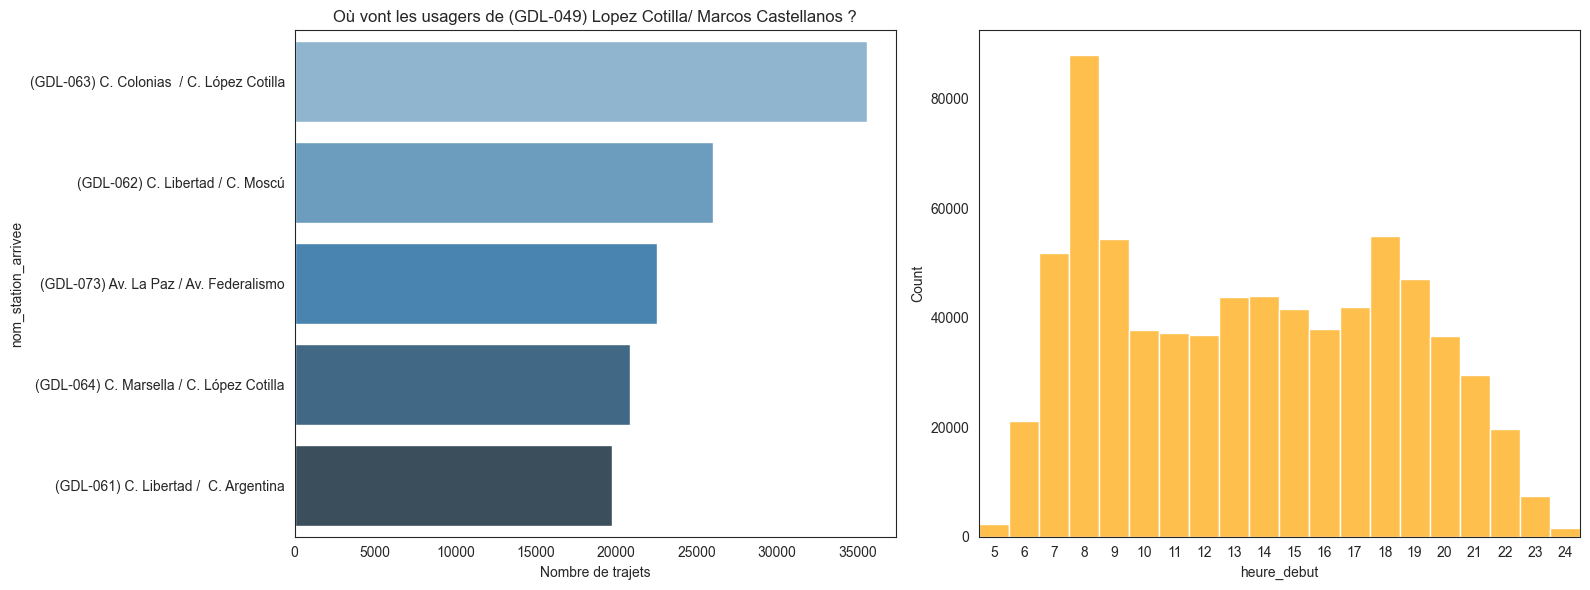

In [63]:
station_id("(GDL-049) Lopez Cotilla/ Marcos Castellanos")

Analyse de la station (EX-ZPN-023) ayant une faible activité et une dispersion faible

--- Fiche d'identité : EX-ZPN-023 C. Juan Diego / C. Sarcófago ---
Nombre total de départs : 1,445
Nombre de destinations différentes : 45
Durée moyenne des trajets : 7.2 min
Destination la plus fréquente : (ZPN-021) Blvrd. Panamericano/ C.Santa Mónica


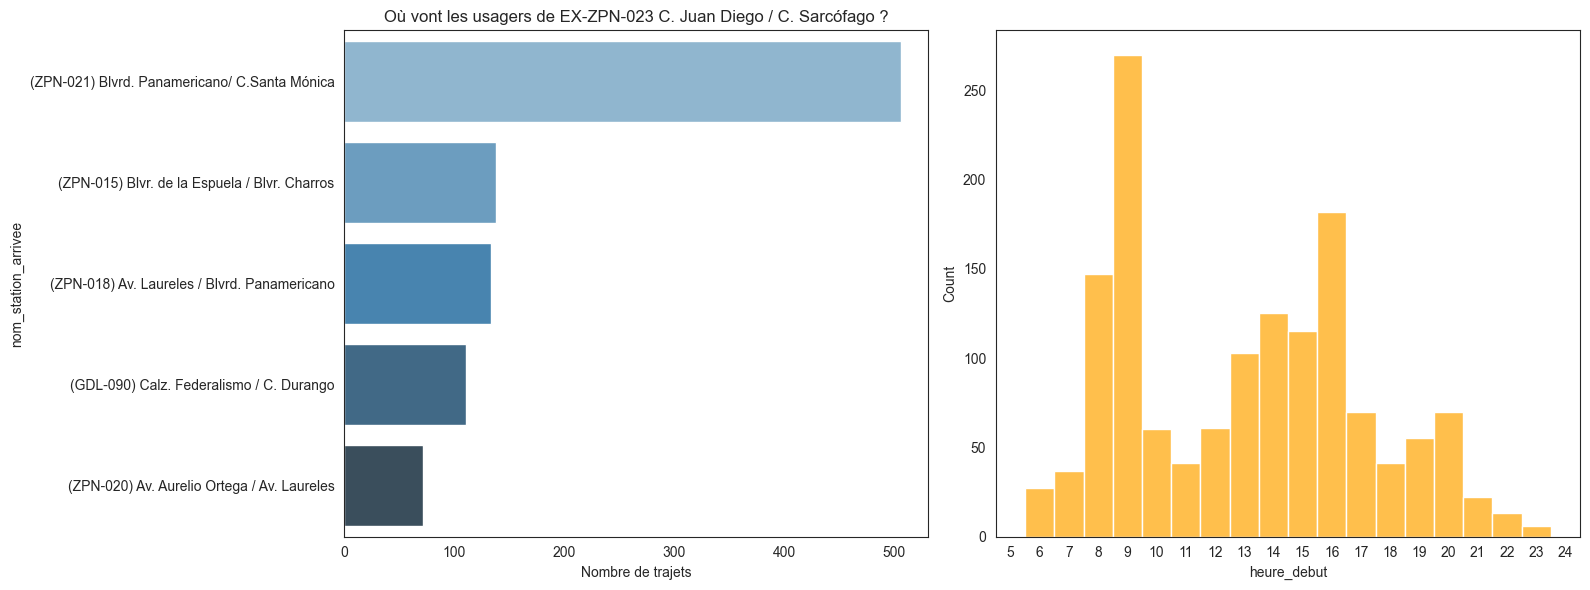

In [64]:
station_id("EX-ZPN-023 C. Juan Diego / C. Sarcófago")

- **Un réseau de "Dernier Kilomètre" (Last Mile)**
Près de 60% des trajets durent entre 5 et 15 minutes avec une durée moyenne autour des 11 minutes confirmant que MiBici est utilisé pour des sauts de puce urbains. C'est l'outil parfait pour compléter les trajets en transports en commun ou remplacer la marche sur des distances de 2 à 3 km.  
Les trajets de moins de 5 minutes constituent un usage du dernier kilomètre, ils représentent environ 17% des usages.  
Quant aux trajets longs, de plus de 30 minutes, ils sont négligeables (moins de 2%), confirmant que Mibici est un réseau pendulaire et non un réseau touristique. (Note : les 30 premières minutes sont gratuites, 45 minutes le dimanche, payantes au-delà)  

- **Hyper-concentration du trafic**
Le réseau est polarisé : les 10 stations les plus actives (sur 382 soit 2,6% du total) captent une part massive de la fréquentation (12%). Cette concentration facilite la maintenance mais crée des goulots d'étranglement aux heures de pointe.

- **Dualité géographique : Périphérie vs Centre**  
L'étude de la dispersion temporelle révèle deux profils de stations distincts :
    - Les pendulaires périphériques (faible dispersion) utilsées pour le trajet domicile/travail ce qui explique les pics d'activité du matin et du soir
    - Les hubs centraux (forte dispersion) qui ont une activité importante tout au long de la journée et nécessitent un réapprovisionnement en vélos constant, contrairement aux périphériques qui fonctionnent par "vagues".

## 4. Logistique et Desequilibres des Flux

--- TOP 5 STATIONS 'SOURCES' (Vides) ---
     nb_departs  nb_arrivees  jours_activite  solde_net  departs_par_jour  arrivees_par_jour  solde_quotidien_moyen
194      361407       211316            3423    -150091        105.581946          61.734151             -43.847794
197      158665       105825            3423     -52840         46.352615          30.915863             -15.436751
196      227685       179775            3429     -47910         66.399825          52.427822             -13.972003
195      130774        87974            3447     -42800         37.938497          25.521903             -12.416594
11       536853       497833            4018     -39020        133.611996         123.900697              -9.711299
--- TOP 5 STATIONS 'PUITS' (Pleines) ---
    nb_departs  nb_arrivees  jours_activite  solde_net  departs_par_jour  arrivees_par_jour  solde_quotidien_moyen
51      735309       965320            4018     230011        183.003733         240.248880              57

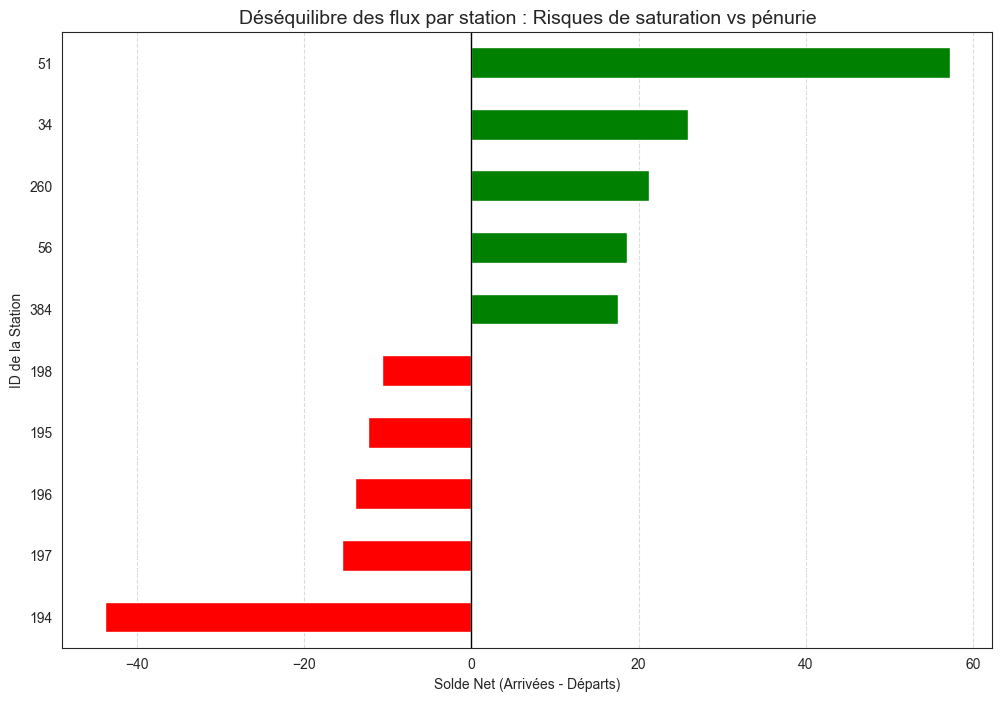

In [ ]:
# Calculer les dates extrêmes pour chaque station (départ et arrivée)
# On cherche quand la station est apparue pour la première fois et sa dernière activité
stats_dates = ddf.groupby('id_depart')['debut_trajet'].agg(['min', 'max']).compute()

# Calculer la durée d'activité en jours pour chaque station
# On ajoute +1 pour éviter les divisions par zéro et compter le jour même
stats_dates['jours_activite'] = (stats_dates['max'] - stats_dates['min']).dt.days + 1
jours_par_station = stats_dates['jours_activite']

# Récupérer tes comptages
departs = ddf.groupby('id_depart').size().compute().rename('nb_departs')
arrivees = ddf.groupby('id_arrivee').size().compute().rename('nb_arrivees')

# Tout fusionner dans un DataFrame final
flux_stations = pd.concat([departs, arrivees, stats_dates['jours_activite']], axis=1).fillna(0)

# Calculer le flux journalier RÉEL (basé sur l'âge de la station)
flux_stations['solde_net'] = flux_stations['nb_arrivees'] - flux_stations['nb_departs']
flux_stations['departs_par_jour'] = flux_stations['nb_departs'] / jours_par_station
flux_stations['arrivees_par_jour'] = flux_stations['nb_arrivees'] / jours_par_station
flux_stations['solde_quotidien_moyen'] = flux_stations['solde_net'] / jours_par_station

print("--- TOP 5 STATIONS 'SOURCES' (Vides) ---")
print(flux_stations.sort_values(by='solde_net').head(5))

print("--- TOP 5 STATIONS 'PUITS' (Pleines) ---")
print(flux_stations.sort_values(by='solde_net', ascending=False).head(5))

# On prend les 10 plus gros déséquilibres de chaque côté
top_vides = flux_stations.sort_values(by='solde_quotidien_moyen').head(5)
top_pleines = flux_stations.sort_values(by='solde_quotidien_moyen', ascending=False).head(5)
extremes = pd.concat([top_vides, top_pleines]).sort_values(by='solde_quotidien_moyen')

plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in extremes['solde_net']]
extremes['solde_quotidien_moyen'].plot(kind='barh', color=colors)

plt.title("Déséquilibre des flux par station : Risques de saturation vs pénurie", fontsize=14)
plt.xlabel("Solde Net (Arrivées - Départs)")
plt.ylabel("ID de la Station")
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

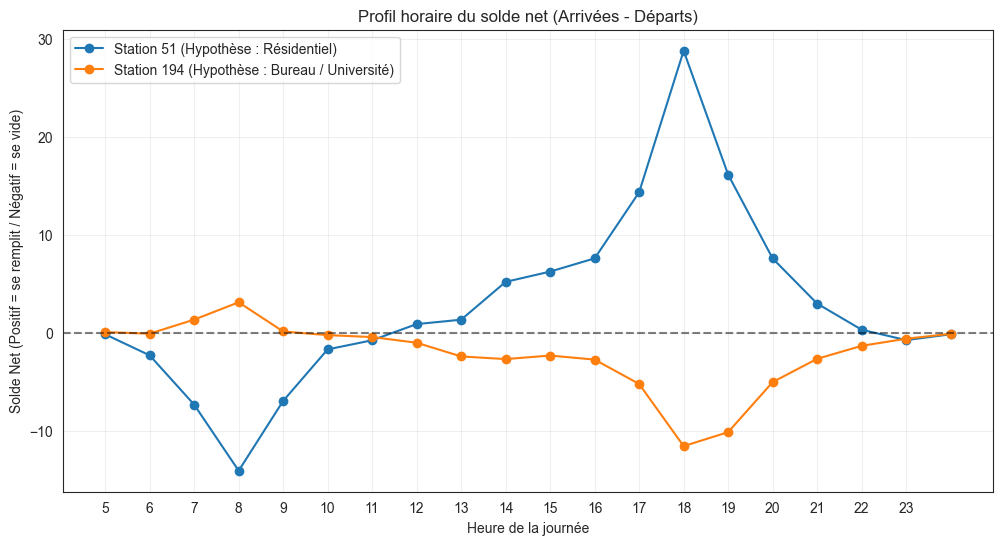

In [ ]:
# Groupement des départs et arrivées par (Station, Heure)
flux_dep = ddf.groupby(['id_depart', 'heure_debut']).size().compute().rename('departs')
flux_arr = ddf.groupby(['id_arrivee', 'heure_debut']).size().compute().rename('arrivees')

# Fusion et calcul du solde
flux_horaire = pd.concat([flux_dep, flux_arr], axis=1).fillna(0)
flux_horaire['solde'] = flux_horaire['arrivees'] - flux_horaire['departs']
flux_horaire.index.names = ['id_station', 'heure']

# Diviser les flux par ce nombre de jours
flux_moyen = flux_horaire.div(jours_par_station, axis=0, level='id_station')

def plot_profil_station(id_station, nom_type):
    data = flux_moyen.xs(id_station, level='id_station').sort_index()
    plt.plot(data.index, data['solde'], marker='o', label=f"Station {id_station} ({nom_type})")

plt.figure(figsize=(12, 6))

# Remplacez ces IDs par des stations suspectées d'être les plus extrêmes
plot_profil_station(51, "Hypothèse : Résidentiel") 
plot_profil_station(194, "Hypothèse : Bureau / Université")

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Profil horaire du solde net (Arrivées - Départs)")
plt.xlabel("Heure de la journée")
plt.ylabel("Solde Net (Positif = se remplit / Négatif = se vide)")
plt.xticks(range(5, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [68]:
# Filtrer pour l'heure de pointe du soir (18h)
flux_18h = ddf[ddf['heure_debut'] == 18]

# Calculer les départs et arrivées par station à cette heure précise
dep_18h = flux_18h.groupby('id_depart').size().compute()
arr_18h = flux_18h.groupby('id_arrivee').size().compute()

# Calculer le solde net de 18h
bilan_18h = pd.DataFrame({'departs': dep_18h, 'arrivees': arr_18h}).fillna(0)
bilan_18h['solde_net_18h'] = (bilan_18h['arrivees'] - bilan_18h['departs']) / jours_par_station

# Trouver le "Champion" de l'accumulation
top_recepteur = bilan_18h.sort_values(by='solde_net_18h', ascending=False).head(5)
print("--- TOP STATIONS RÉCEPTRICES À 18H (Leur stock explose) ---")
print(top_recepteur['solde_net_18h'])

--- TOP STATIONS RÉCEPTRICES À 18H (Leur stock explose) ---
51     28.764062
260     5.475019
58      4.955699
78      4.415733
50      3.451220
Name: solde_net_18h, dtype: float64


In [69]:
# Filtrer les trajets arrivant à la station 51 entre 18h et 19h
flux_vers_51_soir = ddf[(ddf['id_arrivee'] == 51) & (ddf['heure_debut'] == 18)]

# Compter la provenance (id_depart)
origines_51 = flux_vers_51_soir.groupby('id_depart').size().compute()

# Calcul du top 10
top_trajets_vers_51 = origines_51.sort_values(ascending=False).head(10).reset_index()
top_trajets_vers_51.columns = ['Station_Depart', 'Nombre_Total_Trajets']

# Calcul du pourcentage
total_18h = origines_51.sum() # Calcul du total de trajets arrivant à la station 51 à 18h
top_trajets_vers_51['Part_Flux_18h_%'] = (top_trajets_vers_51['Nombre_Total_Trajets'] / total_18h) * 100

print("--- ORIGINES DES TRAJETS ARRIVANT À LA STATION 51 (18h-19h) ---")
print(top_trajets_vers_51)

--- ORIGINES DES TRAJETS ARRIVANT À LA STATION 51 (18h-19h) ---
   Station_Depart  Nombre_Total_Trajets  Part_Flux_18h_%
0             194                  8722         5.116173
1              65                  6528         3.829211
2              66                  5950         3.490166
3             253                  5537         3.247907
4              64                  3951         2.317588
5             199                  3883         2.277700
6              86                  3428         2.010805
7             196                  3363         1.972677
8             197                  3282         1.925164
9              70                  2963         1.738044


**Défis Logistiques : Le Cas d'École de l'Axe 194 ↔ 51**  

L'analyse des flux nets révèle une fracture opérationnelle majeure entre les stations "Source" (qui se vident chroniquement) et les stations "Puits" (qui saturent). Le tandem Station 51 vs Station 194 incarne ce déséquilibre critique.

- **L'Effet Miroir : Source et Puits**  
Station 194 (La Source) : Elle subit une hémorragie quotidienne de -35,7 vélos. Elle se vide massivement le soir, créant une pénurie récurrente pour les usagers au départ.  
Station 51 (Le Puits) : À l'inverse, elle accumule un surplus de +56,4 vélos par jour. Elle sature chaque soir, empêchant les usagers de rendre leur vélo (frustration et pénalités de retard).  

- **L'Heure de Vérité (18h00)**  
C'est en fin de journée que le système craque. À 18h, la station 51 subit un afflux massif (+28,7 vélos/heure) avec une capacité de 33 vélos. Ce n'est pas un hasard : 5,1% de ces arrivées proviennent directement de la station 194, ce chiffre monte à 12,7 % si on s'intéresse au cluster des stations 194, 196, 197, 199  
Ces 4 stations devraient représenter 1% du trafic, il y a donc une sur-représentation d'un facteur 10.  
On observe un second cluster : 64, 65 et 66 représentant près de 10% des arrivées à la station 51.

- **L'Axe Critique**  
Le trajet 194 → 51 est le 4ème itinéraire le plus fréquenté de tout le réseau.  
Les 2 clusters qui réprésentent presque le quart des arrivées à la station 51 à 18h se situent toutes sur l'avenue Ignacio L. Vallarta.  
Ce n'est pas une anomalie, c'est une artère vitale de la ville.

## 5. Conclusions et Recommandations

In [70]:
distance_moyenne = ddf_distance_not_null["distance_km"].mean().compute()
duree_moyenne = ddf["temps_trajet"].mean().compute()

total_trajets = len(ddf)
# Calcul de la distance totale
distance_totale = ddf['distance_km'].sum().compute()
# On utilise le ddf filtré sur la distance non nulle (id_depart = id_arrivee mais durée > 0) pour ne pas fausser les résultats de vitesse
vitesse_moyenne = (ddf_distance_not_null['distance_km'] / (ddf_distance_not_null['temps_trajet']/60)).mean().compute() 

print(f"""
=========================================
   BILAN GLOBAL DU RÉSEAU MIBICI
=========================================
📈 VOLUME : {total_trajets:,} trajets analysés.
📈 POPULARITE : {total_users} utilisateurs uniques.
🌍 IMPACT : {distance_totale:,.0f} km parcourus (soit {distance_totale/40075:.1f} fois le tour de la Terre).
⚡ DISTANCE : {distance_moyenne:.1f} km de distance moyenne parcourue.
⚡ DUREE : {duree_moyenne:.1f} min de temps moyen de trajet.
⚡ EFFICACITÉ : {vitesse_moyenne:.1f} km/h de vitesse moyenne urbaine.
🏆 TOP TRAJET : {top_10_trajets['Trajet'].iloc[0]} 
👤 PROFIL TYPE : Un utilisateur '{repartition_usagers.idxmax()}' effectuant des trajets de '{df_duree_viz.loc[df_duree_viz['Nombre_Trajets'].idxmax(), 'Tranche']}'.
=========================================
""")


   BILAN GLOBAL DU RÉSEAU MIBICI
📈 VOLUME : 34,437,707 trajets analysés.
📈 POPULARITE : 90058 utilisateurs uniques.
🌍 IMPACT : 51,909,311 km parcourus (soit 1295.3 fois le tour de la Terre).
⚡ DISTANCE : 1.6 km de distance moyenne parcourue.
⚡ DUREE : 11.3 min de temps moyen de trajet.
⚡ EFFICACITÉ : 9.0 km/h de vitesse moyenne urbaine.
🏆 TOP TRAJET : (GDL-063) C. Colonias  / C. López Cotilla ➔ (GDL-049) Lopez Cotilla/ Marcos Castellanos 
👤 PROFIL TYPE : Un utilisateur 'Régulier' effectuant des trajets de '5-15 min'.



L'analyse de 34,4 millions de trajets sur une décennie (2015-2025) dresse le portrait d'un service MiBici arrivé à maturité, mais qui fait face à ses propres limites physiques. Passé du statut de nouveauté à celui d'infrastructure critique de transport pendulaire, le réseau est aujourd'hui à la croisée des chemins.

📌 **Synthèse du Diagnostic**  

1. **Saturation Structurelle (Le Mur de 2025)** : La stagnation de la durée des trajets combinée à la baisse du volume (-1,6%) et de l'acquisition (-2,4%) en 2025 indique un plafond de verre. Le réseau actuel ne peut plus absorber de croissance sans dégradation de la qualité de service.

2. **Un Service Pendulaire et Masculin** : Avec une chute de 40% de l'usage le week-end, MiBici est un outil de travail ("Domicile-Travail"). Cependant, il peine à se démocratiser auprès des femmes (stagnation à 27% des usagers), freiné par des enjeux de sécurité nocturne et d'infrastructures.

3. **La Fracture Logistique** : Le réseau souffre d'une hyper-polarisation. Le cas de la Station 51 (saturée par les cluster 194-199 et 64-66 à 18h) montre la nécessité de réguler les flux par camions à cette heure critique.

🚀 **Plan d'Action Recommandé**
Sur la base de ces données, trois axes prioritaires émergent pour l'opérateur :

1. **Pivoter de l'Acquisition vers la Rétention** :
Arrêter les campagnes de recrutement de masse qui saturent le réseau.
Investir le budget marketing dans la densification des stations du Top 10 (ajout de bornettes) pour réduire les échecs de dépôt (Station 51).

2. **Correction des Flux** :
Face au cluster "Ouest → Station 51" (12,7% du flux critique), il faut se concentrer à 18h sur le transfert de vélos de la station 51 au cluster 194-199, sans quoi, la station 51 sera rapidement pleine et les stations du cluster vides.

3. **Sécurité & Inclusion** :
La baisse d'usage féminin après 20h est un signal d'alarme. Une collaboration avec la ville pour renforcer l'éclairage public sur les axes les plus fréquentés est nécessaire pour briser ce plafond de verre des 27%.